In [1]:
%load_ext autoreload
%autoreload 2

<img src="../pic/CU.png" style="width: 100%; display: block; margin: auto;">

# Курс по прогнозированию временных рядов
# Неделя 4. Семинар 1.
# Приведение к стационарности: преобразования и дифференцирование

В ноутбуке `01` мы научились **видеть** нестационарность, в ноутбуке `02` —
**формально её проверять**. Оба раза мы останавливались на диагнозе.
Сегодня — лечение.


## Что мы разберём

| Раздел | Вопрос, на который отвечаем |
|---|---|
| 1 | Почему дисперсия лечится **до** уровня |
| 2 | Бокс-Кокс: подбор $\lambda$, обратное преобразование, поправка на смещение |
| 3 | Дифференцирование: что происходит с рядом и ACF при $d=1$ и $d=2$ |
| 4 | Детерминированный vs стохастический тренд: две симметричные ошибки |
| 5 | Сверхдифференцирование: как выглядит передозировка  |
| 6 | Подбор $d$ по минимуму стандартного отклонения и когда он врёт |
| 7 | Автоматический выбор $d$: пишем `ndiffs` сами и сверяем с библиотекой |
| 8 | Структурный сдвиг маскируется под нестационарность |
| 9 | Мостик к семинару 5: сезонная разность и сила сезонности |


In [2]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss, acf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tools.sm_exceptions import InterpolationWarning

from scipy.stats import boxcox, boxcox_normmax
from scipy.special import inv_boxcox

from utils import tsdisplay, unit_root_report

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["figure.dpi"] = 100

RNG = np.random.default_rng(7)

---
# 1. Сначала дисперсия, потом уровень

## 1.1. Две разные болезни

Слово «нестационарен» скрывает как минимум две принципиально разные
проблемы, и лечатся они разными инструментами:

| Что нестабильно | Как выглядит | Чем лечим |
|---|---|---|
| **Уровень** (среднее) | ряд уплывает вверх/вниз, не возвращается | разность `.diff()` |
| **Дисперсия** (размах) | «раструб»: колебания расширяются со временем | логарифм / Бокс-Кокс |

Разность вычитает соседние значения — она работает с уровнем и ничего не
знает о том, что размах колебаний растёт. Логарифм сжимает большие
значения сильнее маленьких — он работает с размахом и не убирает тренд.

> 🔑 Если у ряда одновременно и тренд, и растущий размах,
> **сначала стабилизируем дисперсию, потом берём разность**. Обратный
> порядок не работает: у разности «раструбного» ряда размах тоже будет
> расти.

## 1.2. Почему порядок именно такой — на данных

Возьмём классический пример: `a10` — ежемесячные продажи
антидиабетических препаратов в Австралии (данные Хайндмана). У ряда есть
всё сразу: рост, сезонность и явно расширяющийся размах.

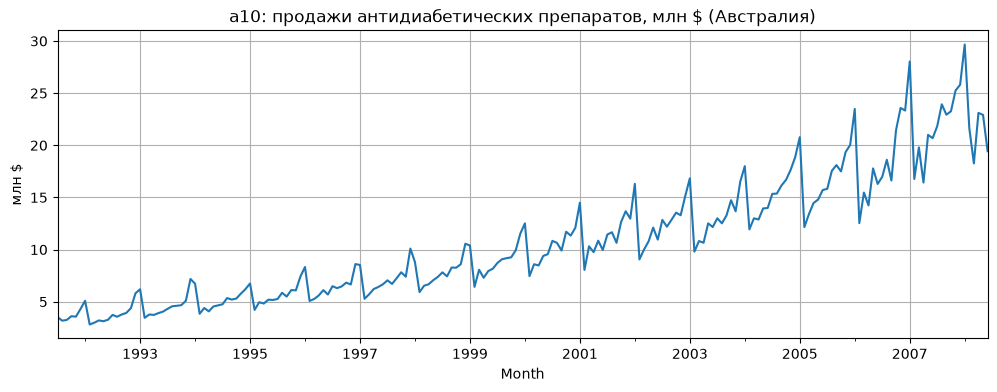

Наблюдений: 204, период: 1991-07 — 2008-06


In [3]:
a10 = pd.read_csv("../data/a10.csv", parse_dates=["Month"]).set_index("Month")["Cost"]
a10 = a10.asfreq("MS")

a10.plot(title="a10: продажи антидиабетических препаратов, млн $ (Австралия)")
plt.ylabel("млн $")
plt.show()

print(f"Наблюдений: {len(a10)}, период: {a10.index.min():%Y-%m} — {a10.index.max():%Y-%m}")

Амплитуда сезонных пиков в начале ряда — примерно 2–3 единицы, в конце —
уже 10–15. Это и есть «раструб».

Теперь сравним два порядка действий на одной картинке.

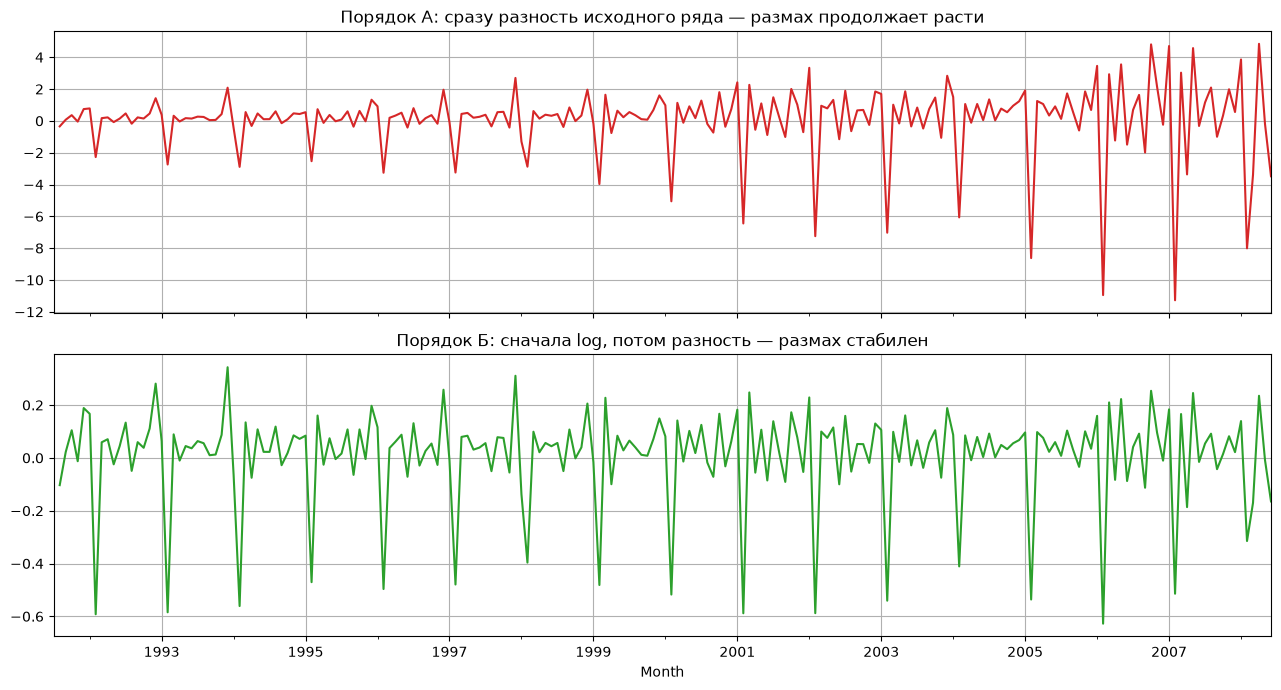

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# Порядок А (неправильный): сначала разность, потом логарифм — логарифм даже
# не применить, в разности есть отрицательные значения. Просто разность:
a10.diff().plot(ax=axes[0], color="tab:red")
axes[0].set_title("Порядок А: сразу разность исходного ряда — размах продолжает расти")

# Порядок Б (правильный): сначала логарифм, потом разность
np.log(a10).diff().plot(ax=axes[1], color="tab:green")
axes[1].set_title("Порядок Б: сначала log, потом разность — размах стабилен")

fig.tight_layout()
plt.show()

Разница видна невооружённым глазом. Подтвердим числом: посчитаем
стандартное отклонение в первой и последней трети каждого ряда.

In [5]:
def spread_report(y, name):
    """Во сколько раз размах в конце ряда больше, чем в начале."""
    y = pd.Series(y).dropna().to_numpy()
    k = len(y) // 3
    first, last = y[:k].std(ddof=1), y[-k:].std(ddof=1)
    return {"ряд": name, "std начала": round(first, 4), "std конца": round(last, 4), "во сколько раз": round(last / first, 2)}


pd.DataFrame(
    [
        spread_report(a10, "a10 (исходный)"),
        spread_report(a10.diff(), "A: diff(a10)"),
        spread_report(np.log(a10), "log(a10)"),
        spread_report(np.log(a10).diff(), "Б: diff(log(a10))"),
    ]
).set_index("ряд")

,std начала,std конца,во сколько раз
ряд,,,
a10 (исходный),1.3701,4.4093,3.22
A: diff(a10),1.0228,3.3208,3.25
log(a10),0.2698,0.2489,0.92
Б: diff(log(a10)),0.1890,0.1851,0.98


У разности исходного ряда размах в конце примерно втрое больше, чем в
начале — то есть проблема с дисперсией никуда не делась, мы просто убрали
тренд. У разности логарифма отношение близко к единице: ряд действительно
стал похож на что-то стационарное.

🔍 Обратите внимание на строку `log(a10)`: после логарифма отношение
размахов уже почти 1, хотя тренд ещё на месте. Это ровно то, за что мы
платим первым шагом — и только после этого имеет смысл думать про $d$.

## 1.3. Порядок действий целиком

```
1. Посмотреть на график.
2. Если размах растёт (или падает) — преобразование дисперсии: log / Бокс-Кокс.   
3. Если есть сезонность и она нужна модели — сезонная разность y.diff(m).         
4. Если уровень всё ещё уплывает — обычная разность y.diff(), при
   необходимости повторить (но почти никогда не больше двух раз).                  
5. Проверить, не перестарались ли: ACF первой разности .                
```

Дальше по разделам разбираем каждый шаг.

---
# 2. Преобразование Бокса-Кокса

## 2.1. Семейство преобразований

Логарифм — не единственный вариант. Бокс и Кокс предложили целое
семейство, управляемое одним параметром $\lambda$:

$$
w_t = \begin{cases}
\log(y_t), & \lambda = 0 \\[4pt]
\dfrac{y_t^{\lambda} - 1}{\lambda}, & \lambda \ne 0
\end{cases}
$$

Смысл параметра:

| $\lambda$ | Что получается | Насколько сильно «сжимает» |
|---|---|---|
| $1$ | $y_t - 1$ — ряд по сути не меняется | никак |
| $0.5$ | квадратный корень | слабо |
| $0$ | логарифм | сильно |
| $-1$ | обратная величина $1 - 1/y_t$ | очень сильно |

Чем меньше $\lambda$, тем сильнее преобразование прижимает большие
значения к маленьким — то есть тем сильнее оно борется с раструбом.

⚠️ **Важное ограничение:** Бокс-Кокс определён только для строго
положительных $y_t$. Для рядов с нулями и отрицательными значениями
нужны варианты вроде Йео-Джонсона или сдвиг $y_t + c$.

Формула написана так, что при $\lambda \to 0$ выражение
$(y^\lambda - 1)/\lambda$ непрерывно переходит в $\log y$ — проверим это
численно, чтобы «случай $\lambda=0$» не выглядел искусственной заплаткой.

In [6]:
y0 = 5.0
print(f"log({y0}) = {np.log(y0):.10f}")
for lam in [0.1, 0.01, 0.001, 0.0001]:
    print(f"λ = {lam:<8} → (y^λ - 1)/λ = {(y0**lam - 1) / lam:.10f}")

log(5.0) = 1.6094379124
λ = 0.1      → (y^λ - 1)/λ = 1.7461894309
λ = 0.01     → (y^λ - 1)/λ = 1.6224591267
λ = 0.001    → (y^λ - 1)/λ = 1.6107337527
λ = 0.0001   → (y^λ - 1)/λ = 1.6095674339


Посмотрим, как одно и то же семейство действует на наш ряд `a10` при
разных $\lambda$.

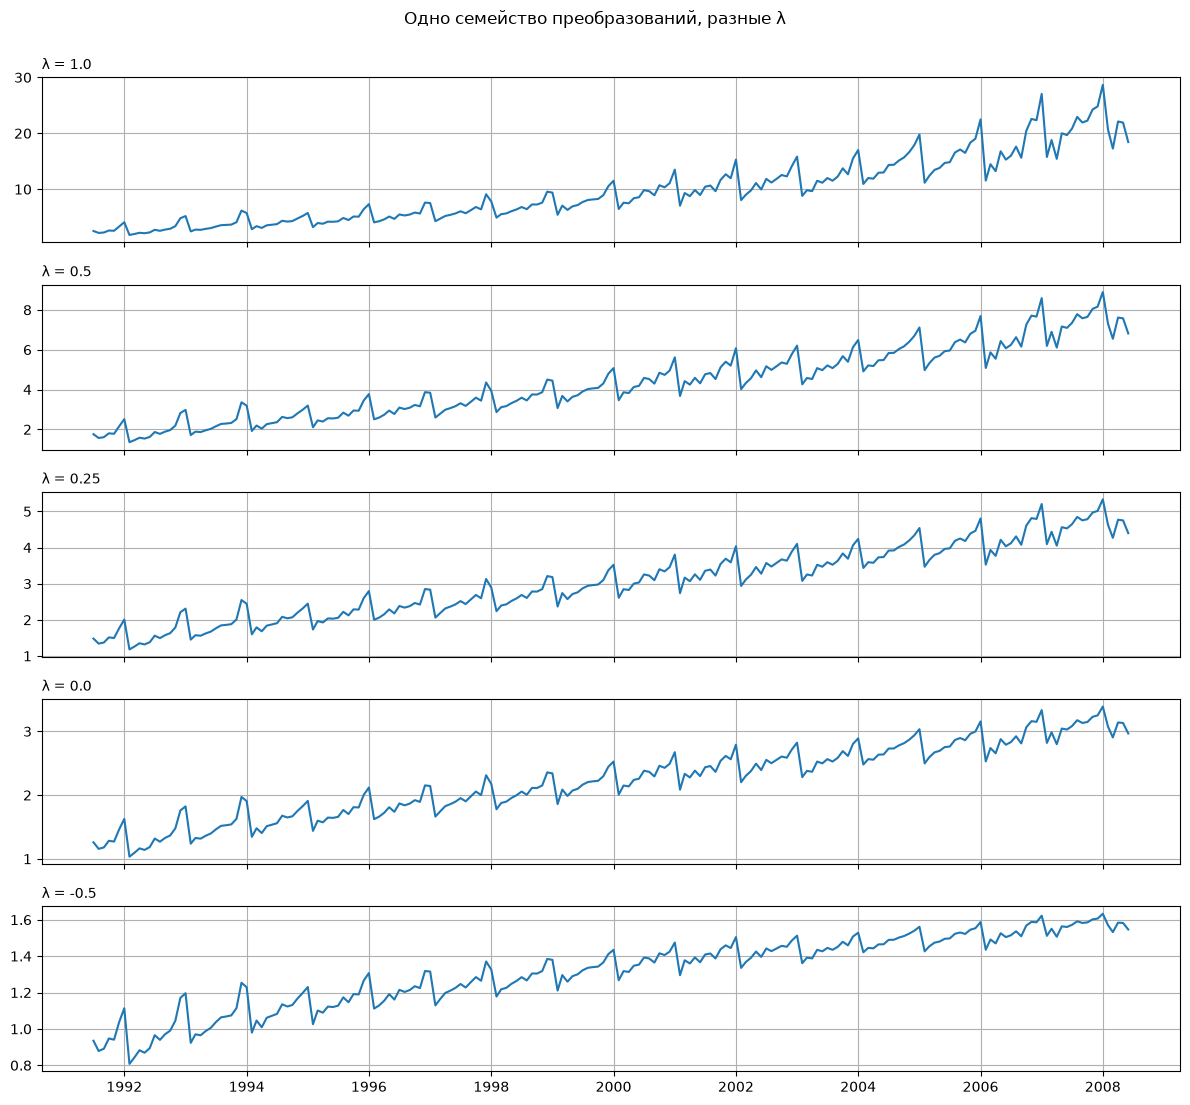

In [7]:
lambdas = [1.0, 0.5, 0.25, 0.0, -0.5]

fig, axes = plt.subplots(len(lambdas), 1, figsize=(12, 11), sharex=True)
for ax, lam in zip(axes, lambdas):
    ax.plot(a10.index, boxcox(a10.to_numpy(), lmbda=lam))
    ax.set_title(f"λ = {lam}", loc="left", fontsize=10)
fig.suptitle("Одно семейство преобразований, разные λ", y=1.0)
fig.tight_layout()
plt.show()

При $\lambda=1$ (верхняя панель) раструб на месте — это исходный ряд с
точностью до сдвига. По мере уменьшения $\lambda$ сезонные пики
«подравниваются». При $\lambda=-0.5$ (нижняя панель) видно
**передозировку в обратную сторону**: теперь размах в начале ряда больше,
чем в конце. Значит, оптимум где-то посередине.

## 2.2. Как подобрать $\lambda$

**Метод максимального правдоподобия** (`scipy.stats.boxcox_normmax` с
`method='mle'`). Ищет $\lambda$, при котором преобразованные данные
максимально похожи на нормальные. Работает быстро и есть «из коробки».


In [8]:
lam_mle = boxcox_normmax(a10.to_numpy(), method="mle")
print(f"λ по методу максимального правдоподобия: {lam_mle:.4f}")

λ по методу максимального правдоподобия: 0.0615


## 2.3. Что преобразование делает с ACF

Влияние на ACF часто недооценивают. Посмотрим на панели до и после.

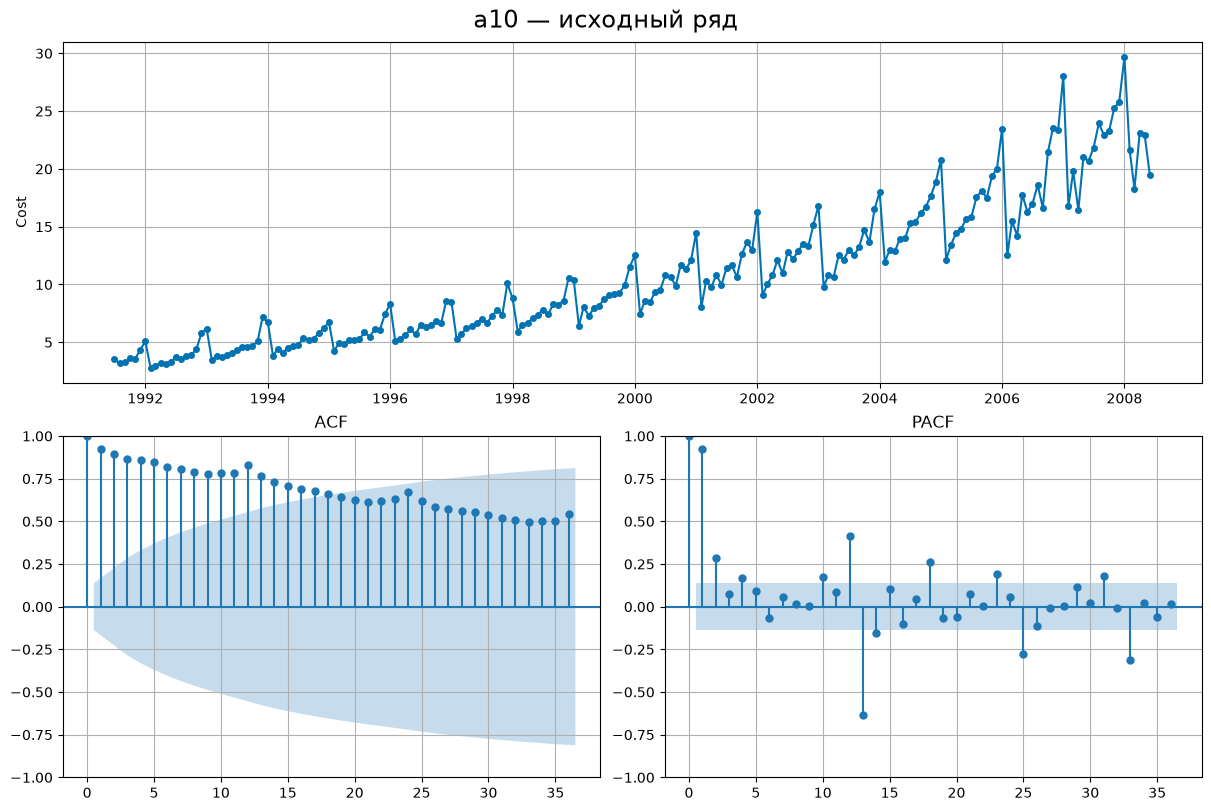

<Figure size 1300x600 with 0 Axes>

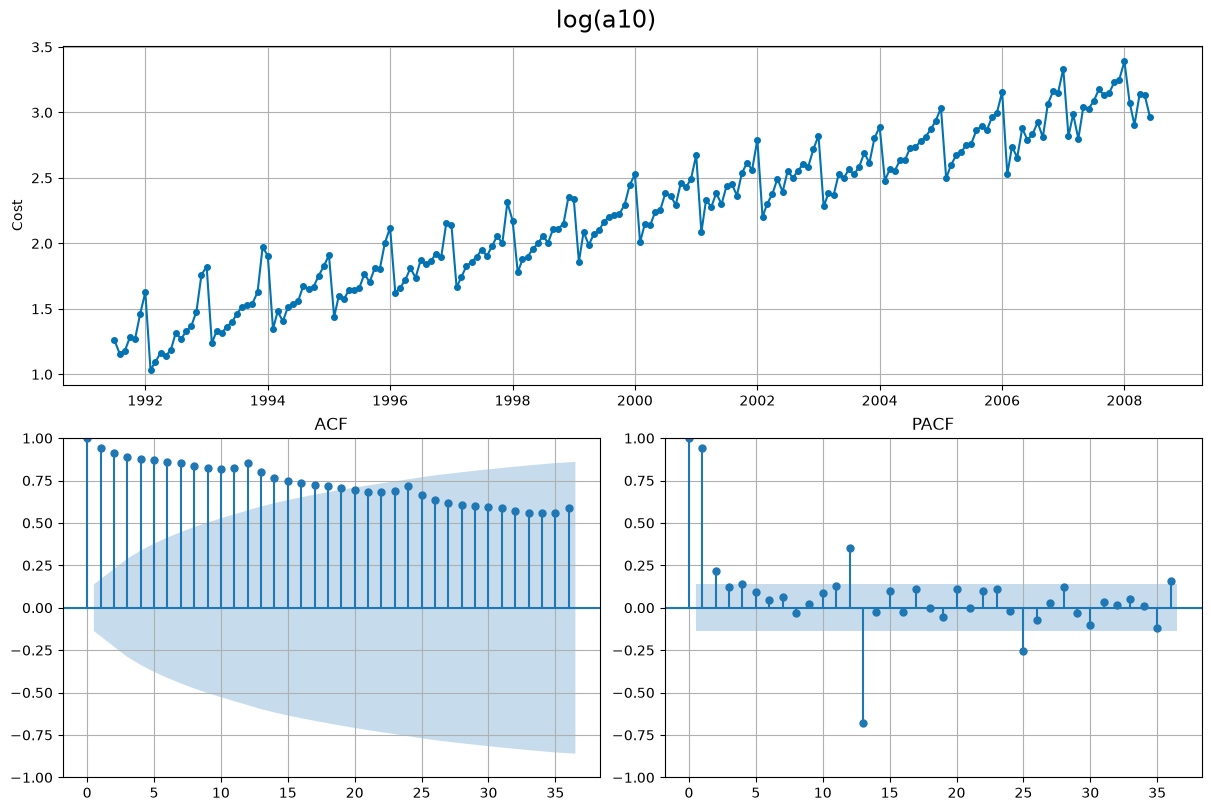

<Figure size 1300x600 with 0 Axes>

In [9]:
tsdisplay(a10, lags=36, title="a10 — исходный ряд")
plt.show()

tsdisplay(np.log(a10), lags=36, title="log(a10)")
plt.show()

Форма ACF почти не изменилась — и это ожидаемо: логарифм монотонен, он не
трогает порядок значений и потому слабо влияет на автокорреляционную
структуру. Медленное затухание никуда не делось, сезонные всплески на
лагах 12, 24 — тоже.

> 🔑 **Вывод, который надо усвоить:** преобразование дисперсии **не
> заменяет** разность. Оно только приводит ряд в тот вид, в котором
> разность (и потом ARIMA) будет работать корректно. Ответ на вопрос
> «сколько разностей брать» даёт следующий раздел.

## 2.4. Обратное преобразование

Мы прогнозируем не сам ряд, а его преобразование. Значит, прогноз надо
вернуть в исходные единицы. Формально это просто:

$$
y = \begin{cases}
\exp(w), & \lambda = 0 \\[4pt]
(\lambda w + 1)^{1/\lambda}, & \lambda \ne 0
\end{cases}
$$


In [10]:
from scipy.special import inv_boxcox

---
# 3. Дифференцирование

## 3.1. Что такое разность

Первая разность — это ряд приращений:

$$y'_t = y_t - y_{t-1}$$

Через лаг-оператор из ноутбука `02`: $y'_t = (1 - L) y_t$. Вторая разность
— разность от разности:

$$y''_t = y'_t - y'_{t-1} = y_t - 2y_{t-1} + y_{t-2} = (1-L)^2 y_t$$

⚠️ Вторая разность — это **не** $y_t - y_{t-2}$. Частая ошибка:
`y.diff(2)` в pandas берёт разность с лагом 2, а нужна `y.diff().diff()`.
Проверим разницу на числах.

In [11]:
demo = pd.Series([1, 4, 9, 16, 25, 36], name="y")  # квадраты: y_t = t²
pd.DataFrame(
    {
        "y": demo,
        "y.diff()": demo.diff(),
        "y.diff().diff()  ← вторая разность": demo.diff().diff(),
        "y.diff(2)  ← лаг 2, НЕ вторая разность": demo.diff(2),
    }
)

,y,y.diff(),y.diff().diff() ← вторая разность,"y.diff(2) ← лаг 2, НЕ вторая разность"
0,1,NaN,NaN,NaN
1,4,3.0,NaN,NaN
2,9,5.0,2.0,8.0
3,16,7.0,2.0,12.0
4,25,9.0,2.0,16.0
5,36,11.0,2.0,20.0


Для ряда $y_t = t^2$ вторая разность — константа 2 (как вторая производная
параболы), а `diff(2)` даёт растущий ряд. Это разные операции.

Каждая разность «съедает» одно наблюдение: после $d$ разностей у нас на
$d$ точек меньше.

## 3.2. Реальный ряд: ВВП США

Возьмём квартальный реальный ВВП США из встроенных данных `statsmodels` —
растущий ряд с ускорением, классический кандидат на обсуждение «$d=1$ или
$d=2$?».

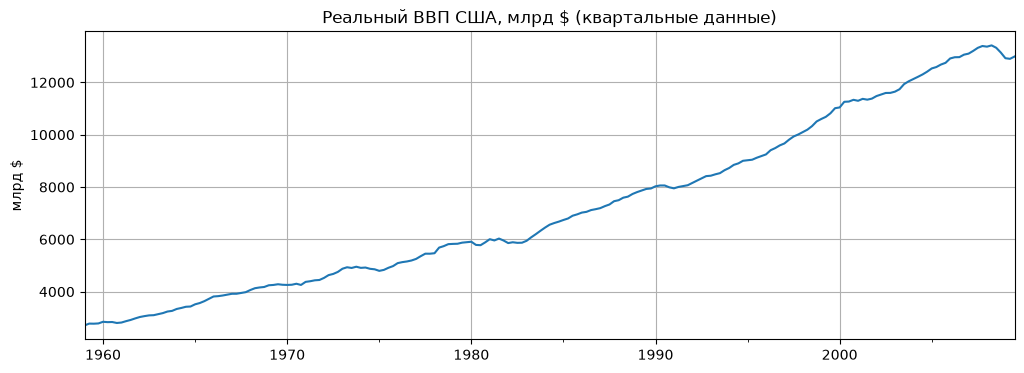

In [12]:
macro = sm.datasets.macrodata.load_pandas().data
gdp = pd.Series(
    macro["realgdp"].to_numpy(),
    index=pd.period_range("1959Q1", periods=len(macro), freq="Q").to_timestamp(),
    name="realgdp",
)

gdp.plot(title="Реальный ВВП США, млрд $ (квартальные данные)")
plt.ylabel("млрд $")
plt.show()

Ряд растёт и растёт с ускорением — размах квартальных приращений в конце
явно больше, чем в начале. Значит, по правилу 15 первым шагом идёт
логарифм: доллары 1960 года и доллары 2008-го — разные величины, а
логарифм переводит ряд в шкалу **относительных** изменений.

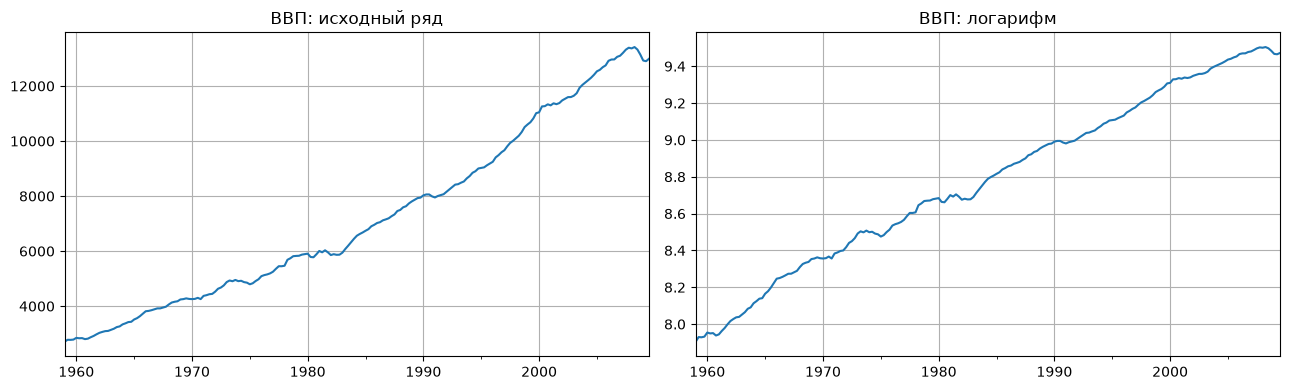

In [13]:
log_gdp = np.log(gdp)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
gdp.plot(ax=axes[0], title="ВВП: исходный ряд")
log_gdp.plot(ax=axes[1], title="ВВП: логарифм")
fig.tight_layout()
plt.show()

После логарифма ряд стал почти прямой линией — экспоненциальный рост
превратился в линейный. Это ровно то, что нам нужно перед разностью.

## 3.3. Шаг за шагом: $d=0$, $d=1$, $d=2$

Посмотрим на панели `tsdisplay` для каждого $d$ и научимся читать их.

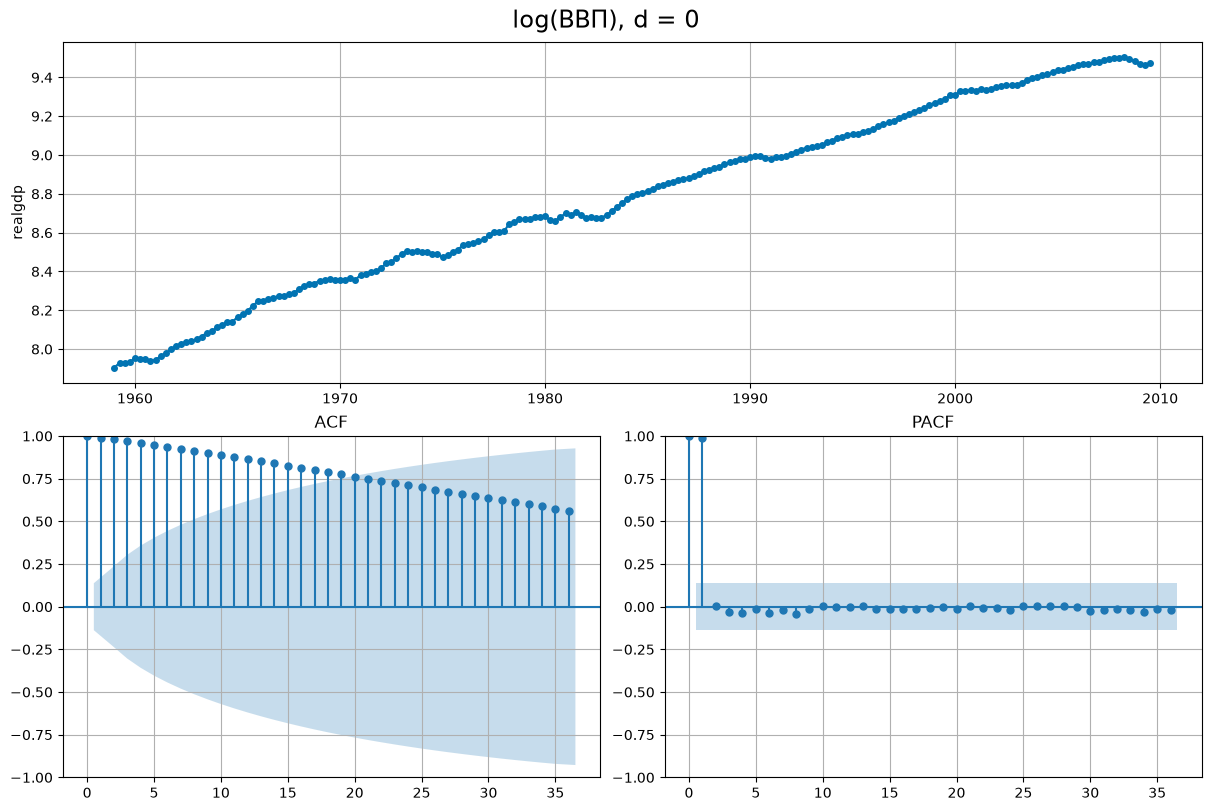

<Figure size 1300x600 with 0 Axes>

In [14]:
tsdisplay(log_gdp, lags=36, title="log(ВВП), d = 0")
plt.show()

**$d=0$.** ACF затухает мучительно медленно — почти линейно, все 36 лагов
значимы. Это тот самый «правило 1» из ноутбука `01`: **медленно затухающая
положительная ACF ⇒ ряд нестационарен, нужна разность.**

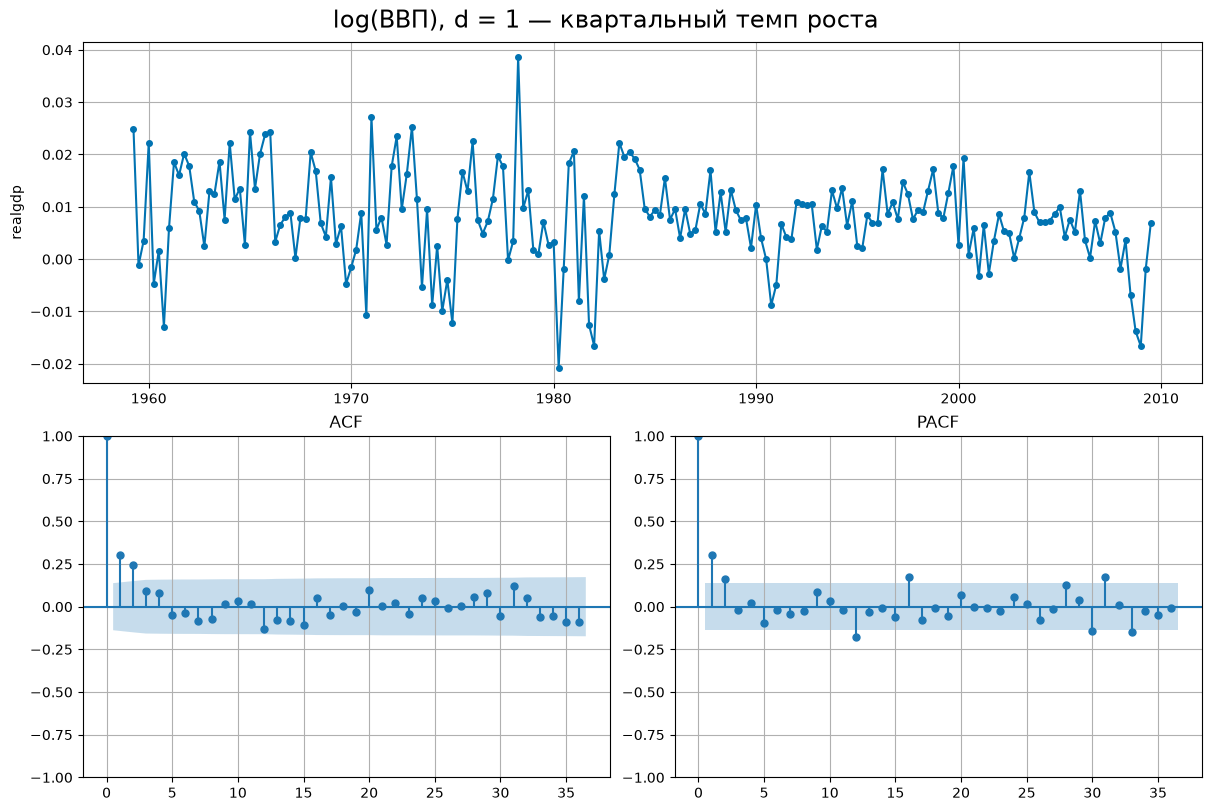

<Figure size 1300x600 with 0 Axes>

In [15]:
tsdisplay(log_gdp.diff().dropna(), lags=36, title="log(ВВП), d = 1 — квартальный темп роста")
plt.show()

**$d=1$.** Картина изменилась кардинально. Ряд колеблется вокруг
постоянного положительного уровня (примерно 0.008 — средний квартальный
темп роста, около 0.8%). ACF резко обрушивается: значимы только первые
несколько лагов, дальше всё внутри доверительных границ. Это уже похоже на
стационарный процесс с небольшой автокорреляцией — как раз то, что дальше
будет моделировать ARMA-часть.

Заметно проседание в конце ряда — это рецессия 2008 года. Стационарности
оно не отменяет, но объясняет, почему мы увидим тяжёлые хвосты.

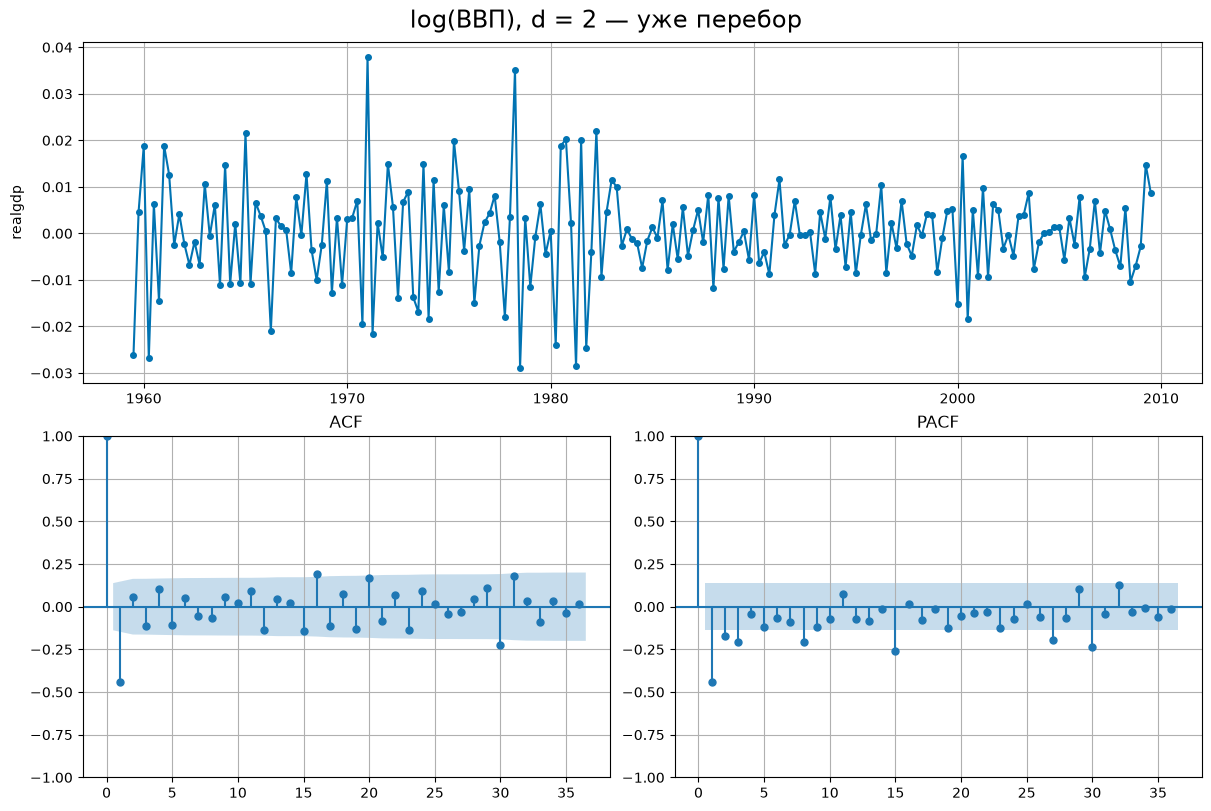

<Figure size 1300x600 with 0 Axes>

In [16]:
tsdisplay(log_gdp.diff().diff().dropna(), lags=36, title="log(ВВП), d = 2 — уже перебор")
plt.show()

**$d=2$.** А вот и передозировка. Смотрим на первый лаг ACF: он ушёл
**глубоко в минус**, примерно к $-0.5$. Дальше ACF «пилит» вокруг нуля.
Это фирменный признак сверхдифференцирования — подробно разберём его в
разделе 5.

Соберём числа в таблицу.

In [17]:
def diff_summary(y, dmax=3, name=""):
    """Сводка по d: std, первая автокорреляция, тесты."""
    values = pd.Series(y).dropna().to_numpy(dtype=float)
    rows = []
    for d in range(dmax + 1):
        z = np.diff(values, n=d) if d else values
        row = {"d": d, "n": len(z), "std": round(z.std(ddof=1), 5), "ACF(1)": round(acf(z, nlags=1)[1], 3)}
        report = unit_root_report(z)
        row["ADF p"] = report["ADF p"]
        row["KPSS p"] = report["KPSS p"]
        row["вердикт"] = report["вердикт"]
        rows.append(row)
    return pd.DataFrame(rows).set_index("d")


diff_summary(log_gdp, dmax=3)

,n,std,ACF(1),ADF p,KPSS p,вердикт
d,,,,,,
0,203,0.46562,0.985,0.3828,0.0100,нестационарен ⇒ нужна разность
1,202,0.00880,0.302,0.0000,0.1000,стационарен
2,201,0.01035,-0.441,0.0000,0.0417,противоречие ⇒ ни то ни сё
3,200,0.01751,-0.669,0.0000,0.1000,стационарен


Читаем таблицу:

* **$d=0$** — оба теста согласны: нестационарен, нужна разность.
* **$d=1$** — оба теста согласны: стационарен. Плюс минимальный `std`.
  **Это наш ответ.**
* **$d=2, 3$** — ADF по-прежнему уверенно отвергает единичный корень
  (и это правда: сверхдифференцированный ряд стационарен!), KPSS
  капризничает. Но `std` начал расти, а `ACF(1)` провалилась
  к $-0.44$ и дальше к $-0.67$.

Обратите внимание: единственный сигнал «стоп» на строках $d=2,3$ пришёл
**не от тестов**. ADF на них рапортует «стационарен» — формально верно и
практически бесполезно.

> 🔑 **Тесты на единичный корень не защищают от передозировки.** Они
> отвечают на вопрос «нужна ли ещё одна разность?», а не «не взяли ли мы
> лишнюю». Против передозировки работают два других признака: рост `std`
> и провал `ACF(1)` .

## 3.4. Что было бы без логарифма

Пройдём тот же путь, но без первого шага.

In [18]:
diff_summary(gdp, dmax=3)

,n,std,ACF(1),ADF p,KPSS p,вердикт
d,,,,,,
0,203,3214.95604,0.987,0.9982,0.0100,нестационарен ⇒ нужна разность
1,202,60.02088,0.411,0.0000,0.0778,стационарен
2,201,65.23844,-0.420,0.0000,0.0417,противоречие ⇒ ни то ни сё
3,200,109.82412,-0.685,0.0000,0.1000,стационарен


Ответ формально тот же — $d=1$, — но посмотрите, **насколько увереннее**
он получился с логарифмом:

| $d=1$ | без логарифма | с логарифмом |
|---|---|---|
| KPSS p-value | **0.078** — на волосок от 0.05 | **0.100** — уверенно не отвергаем |
| ACF(1) | 0.411 | 0.302 |

Без логарифма мы стоим на границе: чуть другой ряд, чуть другое число
наблюдений, чуть другой способ выбора лагов внутри KPSS — и вердикт
перевернётся на «нужна ещё одна разность». Это не гипотетическая угроза:
в разделе 7.2 мы увидим, что `statsforecast` со своим правилом выбора
лагов на **этом же ряду** выдаёт $d=2$, а на логарифме — $d=1$.


---
# 4. Детерминированный vs стохастический тренд

В ноутбуке `01` (раздел 2.7) мы видели два ряда, которые на глаз выглядят
почти одинаково — оба растут, — но устроены совершенно по-разному:

* **детерминированный тренд:** $y_t = \alpha + \beta t + \varepsilon_t$ —
  прямая плюс шум. Ряд *колеблется вокруг прямой* и никогда от неё далеко
  не уходит.
* **стохастический тренд:** $y_t = y_{t-1} + \mu + \varepsilon_t$ —
  случайное блуждание со сносом. Ряд *накапливает* шоки и может уйти сколь
  угодно далеко от любой прямой.

Лечатся они разными инструментами:

| Тип тренда | Правильное лечение |
|---|---|
| детерминированный | **детрендирование** — вычесть подогнанную прямую (или включить $t$ как регрессор) |
| стохастический | **разность** |

Сегодня нас интересует, **что будет, если перепутать**. Сгенерируем оба
ряда с одинаковым наклоном.

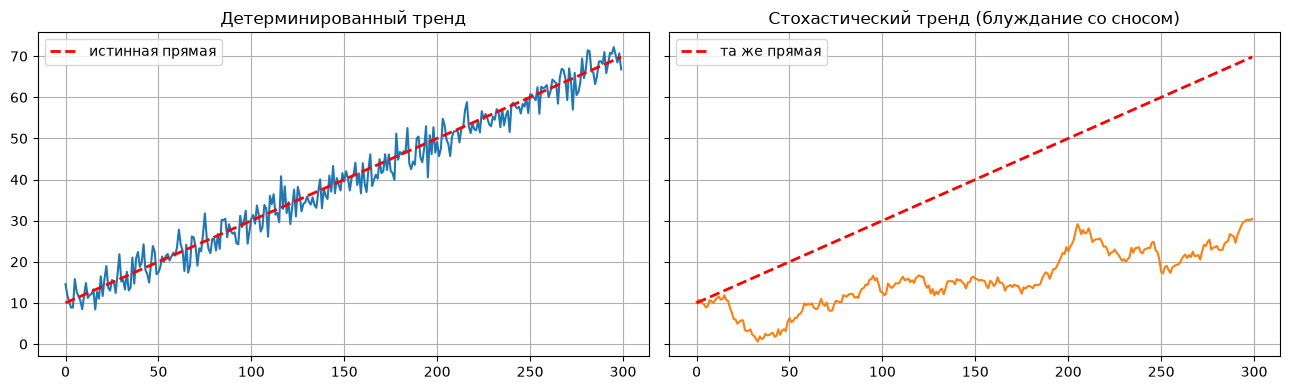

In [19]:
n = 300
t = np.arange(n)
eps = RNG.normal(0, 1, n)

det_trend = 10 + 0.2 * t + 3 * RNG.normal(0, 1, n)  # детерминированный тренд
stoch_trend = 10 + np.cumsum(0.2 + eps)  # стохастический тренд (блуждание со сносом)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
axes[0].plot(det_trend)
axes[0].plot(10 + 0.2 * t, "r--", lw=2, label="истинная прямая")
axes[0].set_title("Детерминированный тренд")
axes[0].legend()
axes[1].plot(stoch_trend, color="tab:orange")
axes[1].plot(10 + 0.2 * t, "r--", lw=2, label="та же прямая")
axes[1].set_title("Стохастический тренд (блуждание со сносом)")
axes[1].legend()
fig.tight_layout()
plt.show()

Разница уже заметна: слева ряд «прилипает» к прямой, справа — уходит от
неё и не собирается возвращаться

## 4.1. Ошибка №1: продифференцировали детерминированный тренд

Что произойдёт математически? Подставим:

$$y'_t = y_t - y_{t-1} = \beta + (\varepsilon_t - \varepsilon_{t-1})$$

Тренд убрался (это хорошо), но вместо белого шума $\varepsilon_t$ мы
получили $\varepsilon_t - \varepsilon_{t-1}$ — это **MA(1) с
$\theta = -1$**, то есть процесс с автокорреляцией первого порядка ровно
$-0.5$. Мы своими руками внесли в ряд структуру, которой там не было.

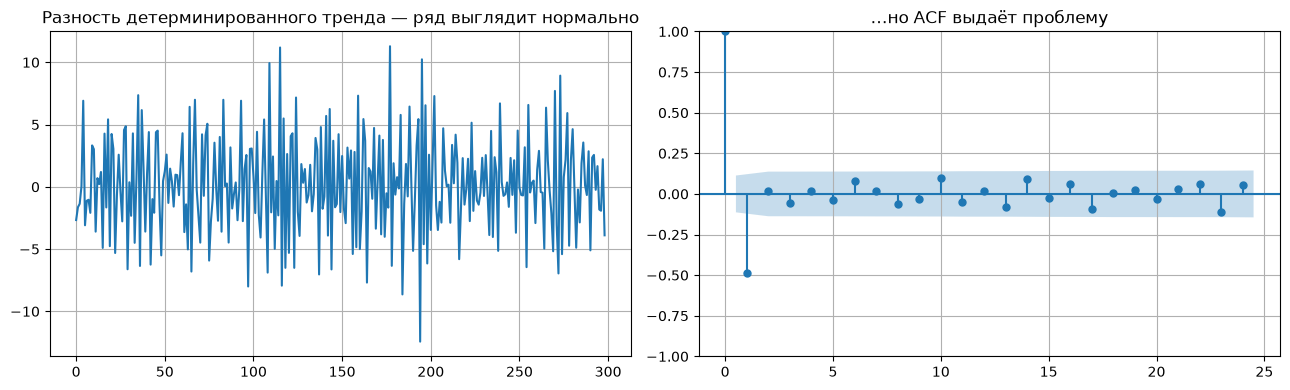

ACF(1) разности детерминированного тренда: -0.484
Теоретическое значение для MA(1) с θ = -1:  -0.500


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(np.diff(det_trend))
axes[0].set_title("Разность детерминированного тренда — ряд выглядит нормально")
plot_acf(np.diff(det_trend), lags=24, ax=axes[1], title="…но ACF выдаёт проблему")
fig.tight_layout()
plt.show()

print(f"ACF(1) разности детерминированного тренда: {acf(np.diff(det_trend), nlags=1)[1]:.3f}")
print("Теоретическое значение для MA(1) с θ = -1:  -0.500")

Ряд-то на глаз стал нормальным, но ACF(1) ≈ $-0.5$ — след
сверхдифференцирования. Сравним с правильным лечением: вычтем прямую,
подогнанную МНК.

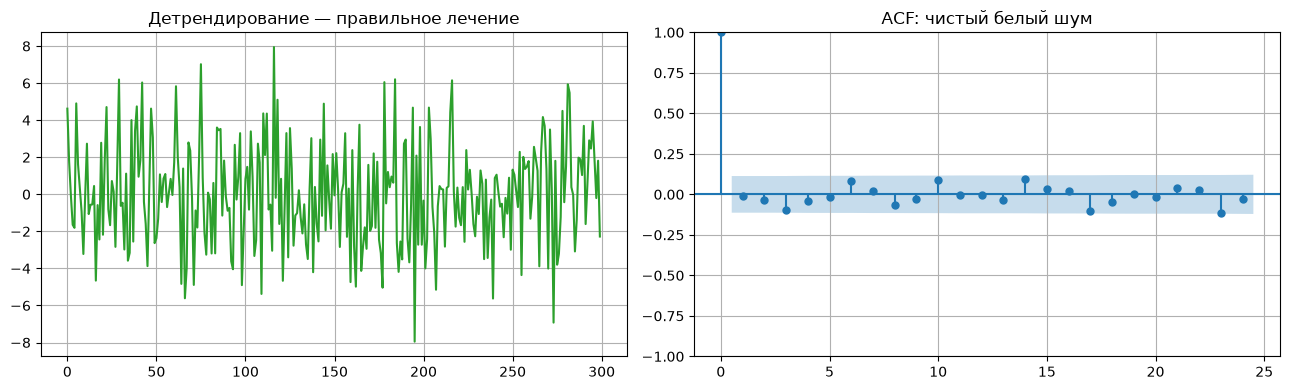

ACF(1) детрендированного ряда: -0.009  (ожидаем ≈ 0)


In [21]:
X = sm.add_constant(t)
detrended = det_trend - sm.OLS(det_trend, X).fit().fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(detrended, color="tab:green")
axes[0].set_title("Детрендирование — правильное лечение")
plot_acf(detrended, lags=24, ax=axes[1], title="ACF: чистый белый шум")
fig.tight_layout()
plt.show()

print(f"ACF(1) детрендированного ряда: {acf(detrended, nlags=1)[1]:.3f}  (ожидаем ≈ 0)")

ACF чистая. Разность вносила артефакт, детрендирование — нет.

## 4.2. Ошибка №2: детрендировали стохастический тренд

Симметричная ошибка. Вычтем из случайного блуждания подогнанную прямую.

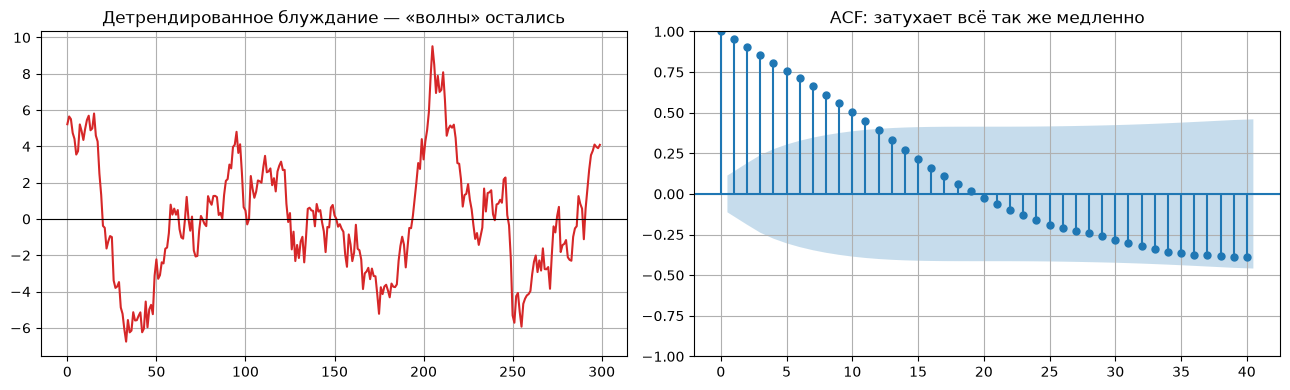

In [22]:
detrended_rw = stoch_trend - sm.OLS(stoch_trend, X).fit().fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(detrended_rw, color="tab:red")
axes[0].axhline(0, color="k", lw=0.8)
axes[0].set_title("Детрендированное блуждание — «волны» остались")
plot_acf(detrended_rw, lags=40, ax=axes[1], title="ACF: затухает всё так же медленно")
fig.tight_layout()
plt.show()

Ряд по-прежнему уплывает большими медленными волнами, ACF по-прежнему
затухает медленно. Прямая вычлась, а нестационарность осталась — потому
что её источник не в прямой, а в накоплении шоков.

А вот разность того же ряда:

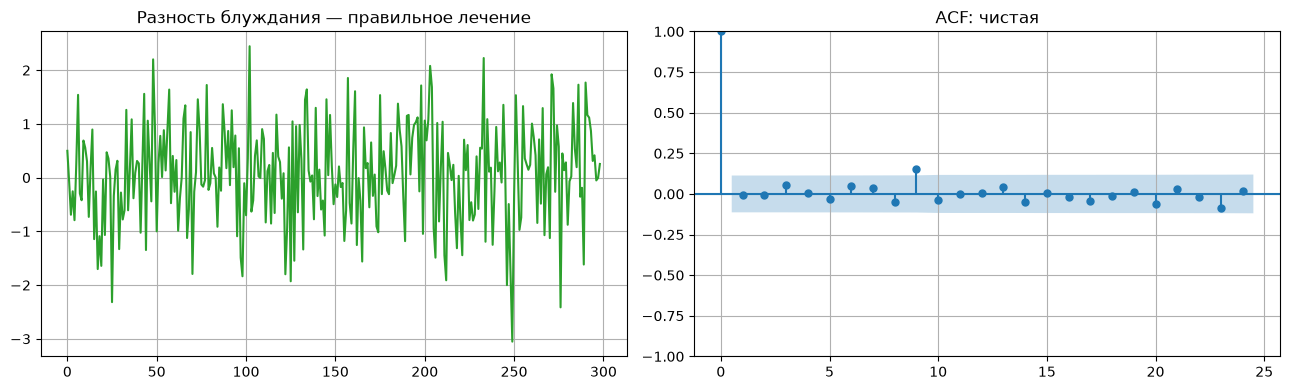

ACF(1) разности блуждания: -0.009  (ожидаем ≈ 0)


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(np.diff(stoch_trend), color="tab:green")
axes[0].set_title("Разность блуждания — правильное лечение")
plot_acf(np.diff(stoch_trend), lags=24, ax=axes[1], title="ACF: чистая")
fig.tight_layout()
plt.show()

print(f"ACF(1) разности блуждания: {acf(np.diff(stoch_trend), nlags=1)[1]:.3f}  (ожидаем ≈ 0)")

## 4.3. Сводка: обе ошибки видны на ACF

In [24]:
pd.DataFrame(
    [
        {"ряд": "детерм. тренд", "лечение": "разность (❌)", "ACF(1)": round(acf(np.diff(det_trend), nlags=1)[1], 3), "диагноз": "сверхдифференцирование"},
        {"ряд": "детерм. тренд", "лечение": "детрендирование (✅)", "ACF(1)": round(acf(detrended, nlags=1)[1], 3), "диагноз": "чисто"},
        {"ряд": "стох. тренд", "лечение": "детрендирование (❌)", "ACF(1)": round(acf(detrended_rw, nlags=1)[1], 3), "диагноз": "нестационарность осталась"},
        {"ряд": "стох. тренд", "лечение": "разность (✅)", "ACF(1)": round(acf(np.diff(stoch_trend), nlags=1)[1], 3), "диагноз": "чисто"},
    ]
).set_index(["ряд", "лечение"])

ACF(1)                    диагноз
ряд           лечение                                               
детерм. тренд разность (❌)         -0.484     сверхдифференцирование
              детрендирование (✅)  -0.009                      чисто
стох. тренд   детрендирование (❌)   0.952  нестационарность осталась
              разность (✅)         -0.009                      чисто

> 🔑 **Как отличить на практике.** Тесты из ноутбука `02` со спецификацией
> `'ct'` (стационарность вокруг тренда) — как раз про это: если ADF со
> спецификацией `'ct'` **отвергает** $H_0$, а с `'c'` — нет, это указывает
> на детерминированный тренд. Проверим на наших двух рядах.

In [25]:
pd.DataFrame(
    [
        unit_root_report(det_trend, "детерм. тренд, spec='c'", adf_spec="c", kpss_spec="c"),
        unit_root_report(det_trend, "детерм. тренд, spec='ct'", adf_spec="ct", kpss_spec="ct"),
        unit_root_report(stoch_trend, "стох. тренд, spec='c'", adf_spec="c", kpss_spec="c"),
        unit_root_report(stoch_trend, "стох. тренд, spec='ct'", adf_spec="ct", kpss_spec="ct"),
    ]
).set_index("ряд")

,ADF p,ADF: ед. корень?,KPSS p,KPSS: стационарен?,вердикт
ряд,,,,,
"детерм. тренд, spec='c'",0.9803,да,0.0100,нет,нестационарен ⇒ нужна разность
"детерм. тренд, spec='ct'",0.0000,нет,0.0321,нет,противоречие ⇒ ни то ни сё
"стох. тренд, spec='c'",0.9258,да,0.0100,нет,нестационарен ⇒ нужна разность
"стох. тренд, spec='ct'",0.2810,да,0.1000,да,мало данных — вывода нет


Ровно та картина, которую мы предсказали:

* детерминированный тренд со спецификацией `'c'` — «нужна разность»
  (неверный вывод), со спецификацией `'ct'` — «стационарен» (верный);
* стохастический тренд не спасает даже `'ct'` — «нужна разность» в обоих
  случаях, и это правильно.

🔍 На реальных данных различие редко бывает таким чистым, и спор
«детерминированный или стохастический тренд» — один из самых
долгоиграющих в эконометрике. Практический компромисс Хайндмана: в
сомнительных случаях брать разность, потому что ошибка в эту сторону
обходится дешевле — сверхдифференцированную модель ARMA-часть ещё может
«починить» MA-членом, а недодифференцированную не починит ничто.

---
# 5. Сверхдифференцирование

Мы уже дважды натыкались на характерный признак. Разберём его как
отдельное явление.

## 5.1. Что происходит при лишней разности

Пусть ряд уже стационарен — например, это белый шум $\varepsilon_t$.
Возьмём разность:

$$y'_t = \varepsilon_t - \varepsilon_{t-1}$$

Это MA(1) с $\theta_1 = -1$. Его теоретическая ACF:

$$\rho_1 = \frac{\theta_1}{1 + \theta_1^2} = \frac{-1}{1 + 1} = -0.5,
\qquad \rho_k = 0 \text{ при } k \ge 2$$

> 🔑 Если ACF(1) продифференцированного ряда $\le -0.5$
> (особенно если ACF при этом «пилит» вокруг нуля), ряд, скорее всего,
> **сверхдифференцирован** — уменьшите $d$.

## 5.2. Демонстрация: три шага для белого шума

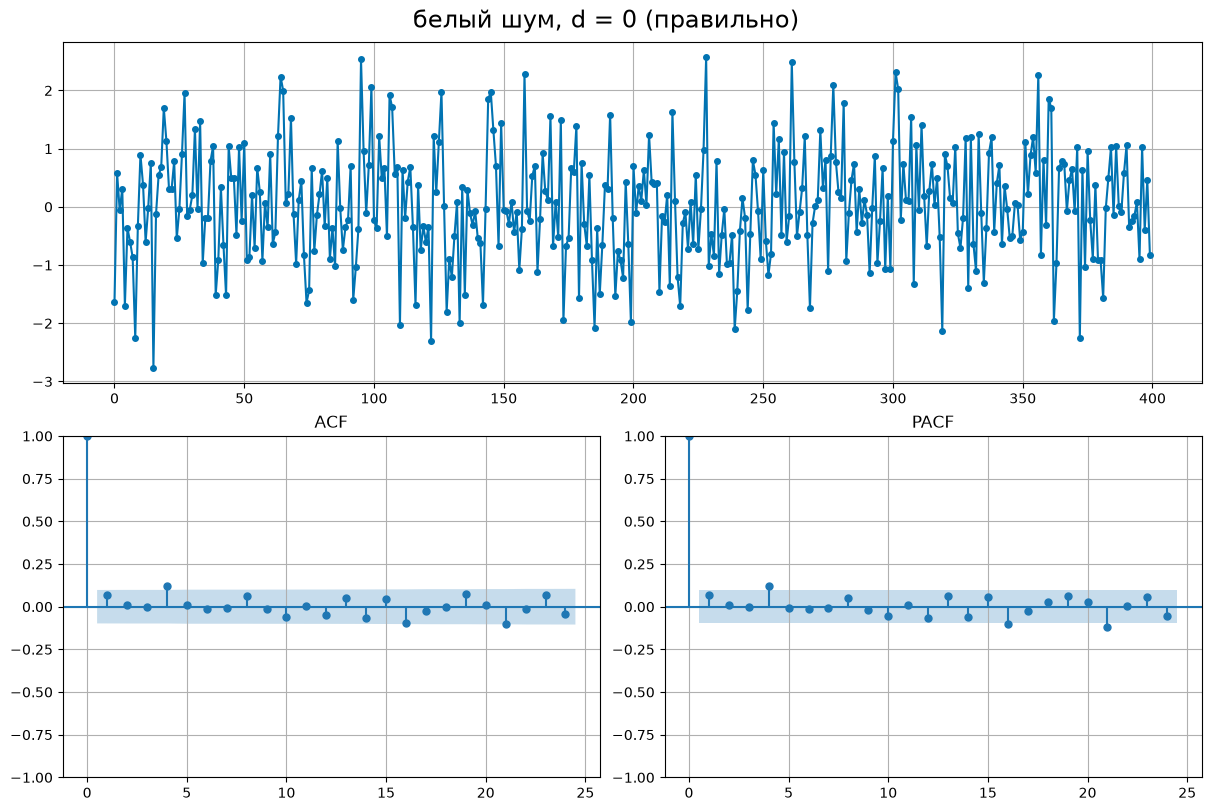

<Figure size 1300x600 with 0 Axes>

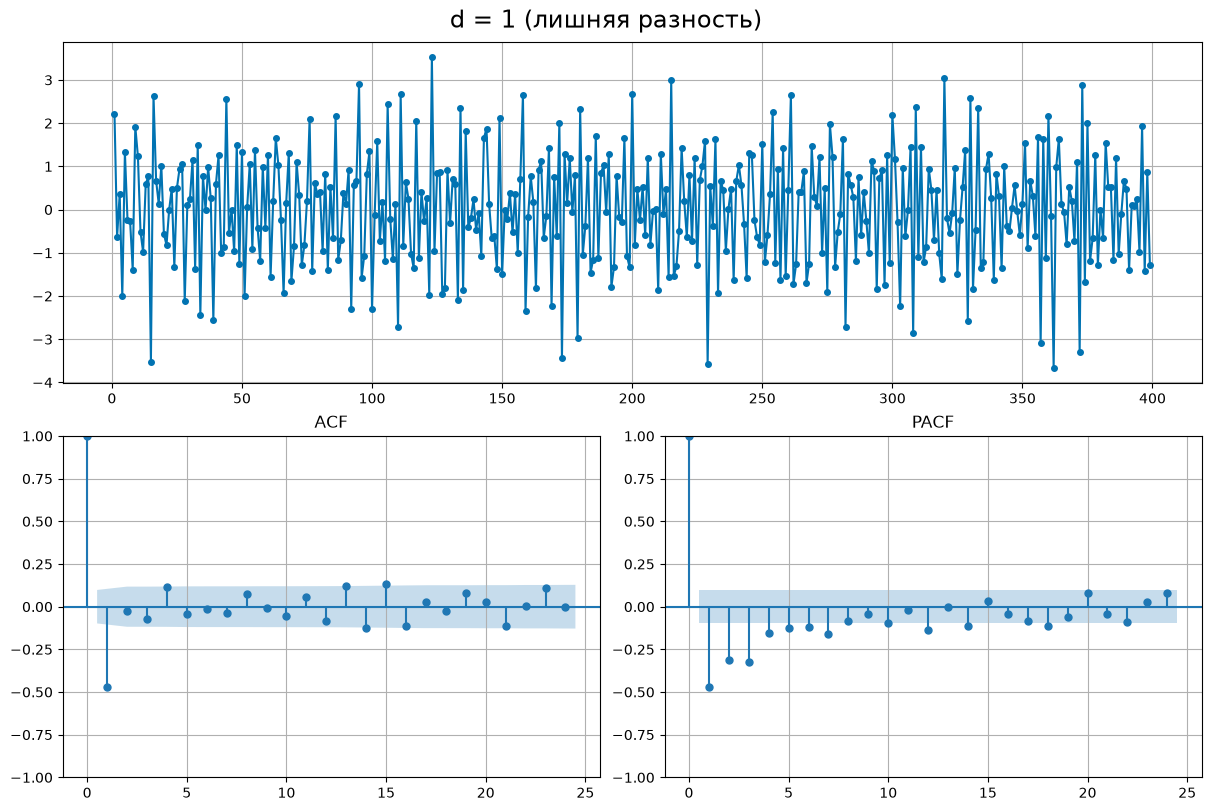

<Figure size 1300x600 with 0 Axes>

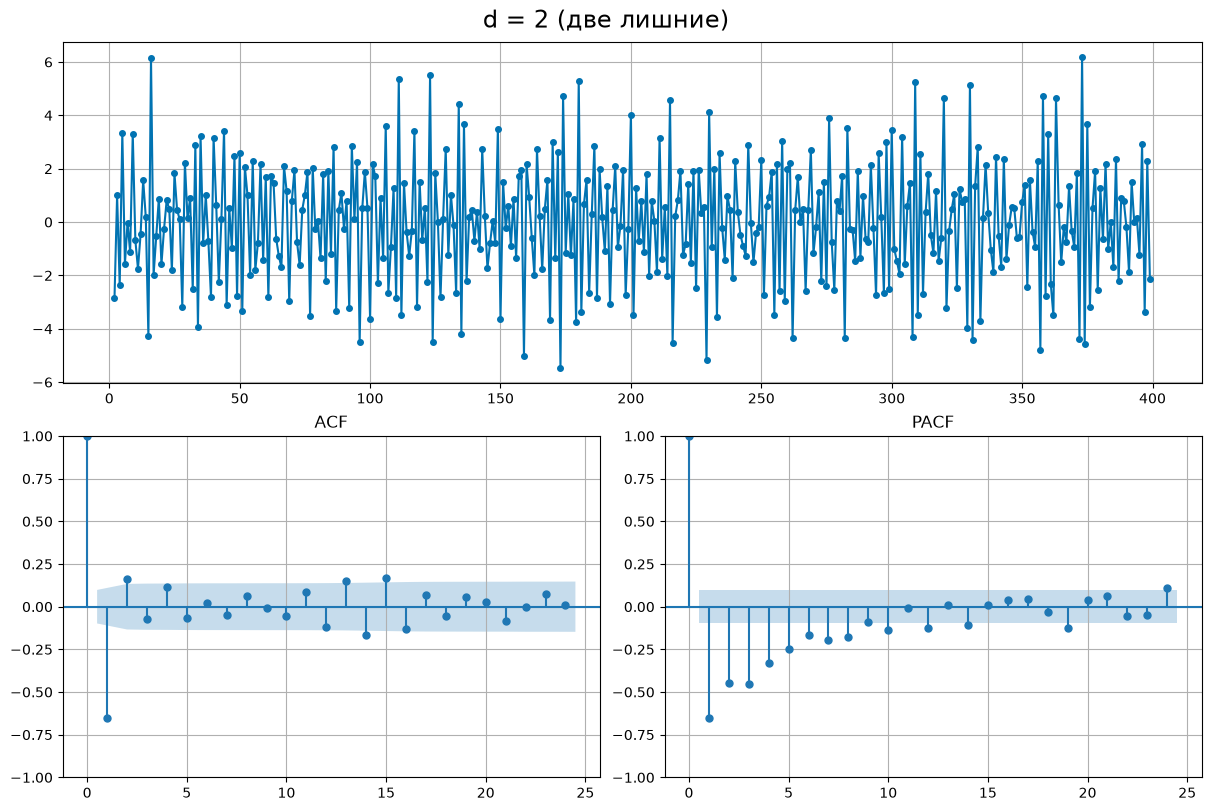

<Figure size 1300x600 with 0 Axes>

In [26]:
wn = pd.Series(RNG.normal(0, 1, 400))

for d, label in [(0, "белый шум, d = 0 (правильно)"), (1, "d = 1 (лишняя разность)"), (2, "d = 2 (две лишние)")]:
    z = wn.diff(1).dropna() if d == 1 else (wn.diff().diff().dropna() if d == 2 else wn)
    tsdisplay(z, lags=24, title=label)
    plt.show()

* **$d=0$** — ACF пустая, как и должно быть у белого шума.
* **$d=1$** — ACF(1) резко ушла в минус, к $-0.5$, дальше ноль. Классика.
* **$d=2$** — теперь ACF «пилит»: значимый минус на лаге 1, значимый плюс
  на лаге 2. Это MA(2) с $\theta_1 = -2$, $\theta_2 = 1$ — процесс,
  который мы породили из ничего.

## 5.3. Три цены передозировки

**Цена 1: растёт дисперсия.** Разность независимых величин имеет бо́льшую
дисперсию, чем сами величины: $\mathrm{Var}(\varepsilon_t -
\varepsilon_{t-1}) = 2\sigma^2$.

In [27]:
values = wn.to_numpy()
pd.DataFrame(
    [
        {"d": d, "std": round(np.diff(values, n=d).std(ddof=1), 4), "во сколько раз больше, чем при d=0": round(np.diff(values, n=d).std(ddof=1) / values.std(ddof=1), 3)}
        for d in range(4)
    ]
).set_index("d")

,std,"во сколько раз больше, чем при d=0"
d,,
0,0.9647,1.000
1,1.3166,1.365
2,2.2540,2.337
3,4.0939,4.244


При $d=1$ стандартное отклонение выросло примерно в $\sqrt{2} \approx 1.41$
раза, при $d=2$ — ещё сильнее. Больше дисперсия остатков ⇒ **шире интервалы
прогноза**. Мы платим точностью за лишний шаг.

**Цена 2: модель становится необратимой.** MA(1) с $\theta_1 = -1$ лежит
**на границе** области обратимости (обратимость требует $|\theta_1| < 1$).
Оптимизатор в такой ситуации упирается в границу, оценки становятся
неустойчивыми, а `statsmodels` начинает ругаться на сходимость. Что такое
обратимость и почему это важно — разберём в семинаре 2, ноутбук `01`.

**Цена 3: модель вынуждена «отменять» лишнюю разность сама.** Подгоним на
белом шуме ARIMA(0, $d$, 1) с правильным и лишним $d$ и посмотрим, что
станет с оценкой $\theta_1$ и с интервалами прогноза.

In [28]:
rows = []
for d in [0, 1, 2]:
    res = ARIMA(wn, order=(0, d, 1), trend="n").fit()
    ci = res.get_forecast(20).conf_int()
    rows.append(
        {
            "модель": f"ARIMA(0,{d},1)",
            "AIC": round(res.aic, 1),
            "θ₁": round(res.params["ma.L1"], 4),
            "σ² остатков": round(res.params["sigma2"], 4),
            "ширина PI, h=1": round(ci.iloc[0, 1] - ci.iloc[0, 0], 3),
            "ширина PI, h=20": round(ci.iloc[-1, 1] - ci.iloc[-1, 0], 3),
        }
    )

pd.DataFrame(rows).set_index("модель")

,AIC,θ₁,σ² остатков,"ширина PI, h=1","ширина PI, h=20"
модель,,,,,
"ARIMA(0,0,1)",1107.8,0.0657,0.9246,3.769,3.777
"ARIMA(0,1,1)",1113.6,-0.9995,0.9310,3.786,3.786
"ARIMA(0,2,1)",1358.4,-0.9999,1.7335,5.167,23.651


Здесь происходит одна из самых поучительных вещей всего ноутбука.
Разберём по строкам.

**$d=0$ (правильно).** $\theta_1 \approx 0$ — MA-член не нужен, это и есть
белый шум. Интервал на горизонте 20 такой же ширины, как на горизонте 1:
у стационарного ряда неопределённость с горизонтом не растёт.

**$d=1$ (лишняя разность).** Смотрим на $\theta_1 \approx -0.99$. Модель
**сама нашла противоядие**: оператор $(1 - L)$, который мы навязали
буквой $d$, почти в точности сократился с оператором $(1 + \theta_1 L)$
при $\theta_1 \to -1$. Поэтому и интервалы почти не расширяются
(3.888 → 3.892), и AIC хуже всего на ~4 пункта.

Но заплатили мы за это трижды: лишний параметр, оценка **на самой границе
области обратимости** ($|\theta_1| < 1$) — там оптимизатор работает
плохо и стандартные ошибки перестают быть надёжными, — и полностью
бессмысленная интерпретация модели.

**$d=2$ (две лишние).** Одного MA-члена уже не хватает, чтобы сократить
два оператора разности. Спасательный механизм не сработал: $\sigma^2$
вырос вдвое, AIC ушёл на 280 пунктов, а интервал на горизонте 20
расширился с 5.6 до 25.4. Модель утверждает, что **через 20 шагов мы
почти ничего не знаем о значении белого шума** — что заведомо неверно.

> 🔑 Отсюда практический вывод, о котором мы говорили в разделе 4.3:
> **одну** лишнюю разность ARMA-часть обычно «чинит» MA-членом с
> $\theta \approx -1$ — потому ошибка в сторону лишней разности и
> считается менее опасной. Но чинит не бесплатно, а две уже не чинит.

⚠️ И заметьте: формальные тесты на стационарность пропускают все три ряда,
а AIC ловит только грубую передозировку ($d=2$), между $d=0$ и $d=1$
разница всего 4 пункта. **Ни AIC, ни ADF/KPSS не защищают от
сверхдифференцирования.** Защищает взгляд на ACF — и на оценку $\theta_1$,
прижавшуюся к $-1$.

---
# 6. Подбор $d$ по минимуму стандартного отклонения

## 6.1. Идея

Из раздела 5 мы знаем: лишняя разность **увеличивает** дисперсию. Из
раздела 3 — что нужная разность её **уменьшает** (убирает тренд, который
и раздувал разброс). Отсюда простое эмпирическое правило:

> 🔑 Считаем `std` ряда при $d = 0, 1, 2, 3$ и берём то $d$,
> при котором `std` минимальна.

Правило подкупает простотой: одна строчка кода, никакой статистики.

In [29]:
def std_by_d(y, dmax=3, name=""):
    values = pd.Series(y).dropna().to_numpy(dtype=float)
    return pd.Series(
        [np.diff(values, n=d).std(ddof=1) for d in range(dmax + 1)],
        index=pd.RangeIndex(dmax + 1, name="d"),
        name=name,
    )


std_table = pd.DataFrame(
    {
        "log(ВВП)": std_by_d(log_gdp, name="log(ВВП)"),
        "log(a10)": std_by_d(np.log(a10), name="log(a10)"),
        "белый шум": std_by_d(wn, name="белый шум"),
        "блуждание": std_by_d(stoch_trend, name="блуждание"),
    }
)
std_table.style.highlight_min(axis=0, color="lightgreen").format("{:.5f}")

,log(ВВП),log(a10),белый шум,блуждание
d,,,,
0,0.46562,0.57139,0.96467,6.99126
1,0.00880,0.18201,1.31662,0.92535
2,0.01035,0.29469,2.25401,1.31623
3,0.01751,0.52577,4.09387,2.28410


Зелёным подсвечен минимум по каждому столбцу. Правило даёт:

* `log(ВВП)` → $d = 1$ ✅ (сходится с разделом 3)
* `log(a10)` → $d = 1$ ✅
* белый шум → $d = 0$ ✅
* блуждание → $d = 1$ ✅

Четыре из четырёх. Но не спешите.

## 6.2. Когда правило врёт

Вернёмся к ряду с **детерминированным** трендом из раздела 4. Мы уже
знаем: правильное лечение для него — детрендирование, а не разность.

In [30]:
det_std = std_by_d(det_trend, name="детерм. тренд")
det_acf = pd.Series([acf(np.diff(det_trend, n=d), nlags=1)[1] for d in range(4)], index=det_std.index, name="ACF(1)")

pd.DataFrame({"std": det_std, "ACF(1)": det_acf}).round(4)

,std,ACF(1)
d,,
0,17.3833,0.9671
1,3.9128,-0.4839
2,6.7460,-0.6682
3,12.3375,-0.7575


Правило 3 уверенно указывает на $d=1$: `std` падает с ~17.7 до ~4.1, потом
растёт. Формально всё сходится — а мы из раздела 4 знаем, что этот ответ
**неверен**: ряд стационарен вокруг детерминированного тренда, разность
вносит артефакт.

Второй столбец сдаёт правило 3 с потрохами: `ACF(1)` при $d=1$ равна
примерно $-0.54$, то есть **ниже $-0.5$** — правило 2 кричит о
сверхдифференцировании там, где правило 3 довольно результатом.

> 🔑 Правило минимума `std` — эвристика, а не
> критерий. Она честно ловит переход «тренд ⇒ нет тренда», но не отличает
> стохастический тренд от детерминированного и не видит передозировки.
> **Всегда проверяйте ответ по ACF (правило 2).**

## 6.3. Как правильно комбинировать правила

Три инструмента дополняют друг друга, и ни один не самодостаточен:

| Инструмент | Что хорошо ловит | Чего не видит |
|---|---|---|
| тесты ADF/KPSS (ноутбук `02`) | «нужна ли ещё разность» | передозировку |
| правило 3 (`std`) | грубый порядок величины $d$ | детерминированный тренд, передозировку |
| правило 2 (`ACF(1)`) | **передозировку** | нехватку разностей |

Рабочая процедура: тесты (или правило 3) дают кандидата на $d$, а правило
2 проверяет, не перебор ли это. Именно так устроен автоматический выбор в
следующем разделе.

---
# 7. Автоматический выбор $d$

## 7.1. Процедура

Алгоритм, который использует `pmdarima.arima.utils.ndiffs` устроен предельно просто:

```
d = 0
пока (тест говорит «нестационарен») и (d < max_d):
    взять разность
    d = d + 1
вернуть d
```

По умолчанию используется **KPSS** (а не ADF), и вот почему это разумно:
у KPSS нулевая гипотеза — «ряд стационарен». Значит, чтобы взять
разность, нужно **активное свидетельство** против стационарности. При
нехватке данных KPSS промолчит и мы останемся с меньшим $d$ — а мы уже
знаем из раздела 5, что лишняя разность стоит дорого. С ADF было бы
наоборот: там $H_0$ — «единичный корень есть», и молчание теста означало
бы лишнюю разность.

Напишем процедуру сами.

In [31]:
def ndiffs_manual(y, test="kpss", alpha=0.05, max_d=2, verbose=True):
    """Итеративный выбор d: «тест → разность → тест». Аналог pmdarima.arima.utils.ndiffs."""
    z = pd.Series(y).dropna().to_numpy(dtype=float)
    d = 0

    def needs_diff(x):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", InterpolationWarning)
            if test == "kpss":
                p = kpss(x, regression="c", nlags="auto")[1]
                return p < alpha, p  # KPSS отверг стационарность ⇒ нужна разность
            p = adfuller(x, regression="c", autolag="AIC")[1]
            return p >= alpha, p  # ADF не отверг единичный корень ⇒ нужна разность

    while d < max_d:
        diff_needed, p = needs_diff(z)
        if verbose:
            print(f"d = {d}: {test.upper()} p-value = {p:.4f} → {'нужна разность' if diff_needed else 'СТОП, стационарен'}")
        if not diff_needed:
            return d
        z = np.diff(z)
        d += 1

    if verbose:
        print(f"d = {d}: достигнут max_d = {max_d}, останавливаемся")
    return d

Прогоним её на знакомых рядах.

In [32]:
print("=== log(ВВП) ===")
d_log_gdp = ndiffs_manual(log_gdp)
print(f"→ d = {d_log_gdp}\n")

print("=== ВВП без логарифма ===")
d_gdp = ndiffs_manual(gdp)
print(f"→ d = {d_gdp}\n")

print("=== белый шум ===")
d_wn = ndiffs_manual(wn)
print(f"→ d = {d_wn}")

=== log(ВВП) ===
d = 0: KPSS p-value = 0.0100 → нужна разность
d = 1: KPSS p-value = 0.1000 → СТОП, стационарен
→ d = 1

=== ВВП без логарифма ===
d = 0: KPSS p-value = 0.0100 → нужна разность
d = 1: KPSS p-value = 0.0778 → СТОП, стационарен
→ d = 1

=== белый шум ===
d = 0: KPSS p-value = 0.1000 → СТОП, стационарен
→ d = 0


Видно, как работает цикл: для `log(ВВП)` KPSS на исходном ряду отвергает
стационарность (p = 0.01), после первой разности — уже нет, останавливаемся
на $d=1$. Без логарифма требуется два шага — тот же эффект правила 15,
который мы разбирали в разделе 3.4.

## 7.2. Сверка с библиотечной реализацией

В `statsforecast` та же процедура доступна как
`statsforecast.arima.ndiffs`. Сверим ответы.

In [33]:
from statsforecast.arima import ndiffs as sf_ndiffs
from pmdarima.arima.utils import ndiffs as pm_ndiffs

series_to_check = {
    "log(ВВП)": log_gdp,
    "ВВП (без log)": gdp,
    "log(a10)": np.log(a10),
    "a10": a10,
    "белый шум": wn,
    "блуждание": pd.Series(stoch_trend),
    "детерм. тренд": pd.Series(det_trend),
    "US Consumption": pd.read_csv("../data/us_change.csv", parse_dates=["Time"]).set_index("Time")["Consumption"],
}

pd.DataFrame(
    [
        {
            "ряд": name,
            "наш ndiffs_manual": ndiffs_manual(s, verbose=False),
            "statsforecast.ndiffs": sf_ndiffs(pd.Series(s).dropna().to_numpy(dtype=float)),
        }
        for name, s in series_to_check.items()
    ]
).set_index("ряд")

,наш ndiffs_manual,statsforecast.ndiffs
ряд,,
log(ВВП),1,1
ВВП (без log),1,2
log(a10),1,1
a10,1,1
белый шум,0,0
блуждание,1,1
детерм. тренд,1,1
US Consumption,0,0


Ответы совпали везде, **кроме одной строки** — и это самая интересная
строка таблицы.

`ВВП (без log)`: наша реализация говорит $d=1$, `statsforecast` — $d=2$.
Мы предупреждали об этом в разделе 3.4: там KPSS после первой разности
дал p-value = 0.078, то есть буквально на волосок от порога 0.05.
Достаточно чуть иначе выбрать число лагов внутри теста — и вердикт
переворачивается. `statsforecast` берёт фиксированное
$\lfloor 3\sqrt{n}/13 \rfloor$ (правило Шверта), мы — `nlags='auto'`.

А на строке `log(ВВП)` обе реализации согласны: $d=1$.


🔍 Отдельно посмотрите на строку `детерм. тренд`: обе реализации выдают
$d=1$ — ту самую ошибку из раздела 4.1. Автоматическая процедура
**не умеет** отличать детерминированный тренд от стохастического, потому
что тест внутри неё вызывается со спецификацией `'c'`, а не `'ct'`.
Это не баг библиотеки — это её сознательное упрощение, и знать о нём нужно.

И строку `US Consumption`: $d=0$. Квартальный рост потребления в США —
редкий случай реального макроэкономического ряда, который стационарен как
есть, без всяких преобразований. Такие ряды тоже бывают, и брать у них
разность «на всякий случай» не надо.


---
# 8. Структурный сдвиг маскируется под нестационарность

Мы закрываем последнюю, самую коварную клетку таблицы 2×2 из ноутбука
`02` — «противоречие». Часто за ней стоит вот такая история.

## 8.1. Ряд, который притворяется нестационарным

Сгенерируем **заведомо стационарный** ряд — белый шум — и добавим ровно
одно событие: с середины уровень скачком вырос на 5. Такое бывает сплошь
и рядом: смена тарифа, запуск нового продукта, изменение методики учёта,
слияние компаний.

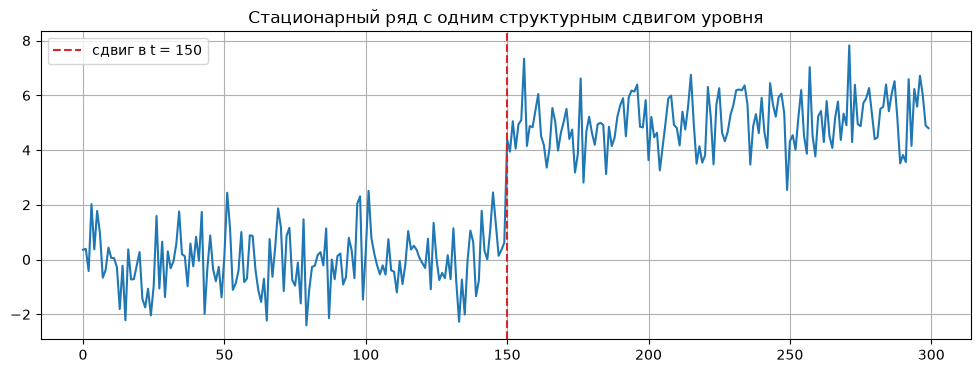

In [34]:
n_break = 300
break_at = 150
base = RNG.normal(0, 1, n_break)
step = (np.arange(n_break) >= break_at).astype(float)
broken = pd.Series(base + 5.0 * step)

broken.plot(title="Стационарный ряд с одним структурным сдвигом уровня")
plt.axvline(break_at, color="tab:red", ls="--", label=f"сдвиг в t = {break_at}")
plt.legend()
plt.show()

Никакой нестационарности здесь по сути нет: до сдвига ряд колеблется
вокруг 0, после — вокруг 5, и в обоих режимах он стационарен. Но что
скажет наша диагностика?

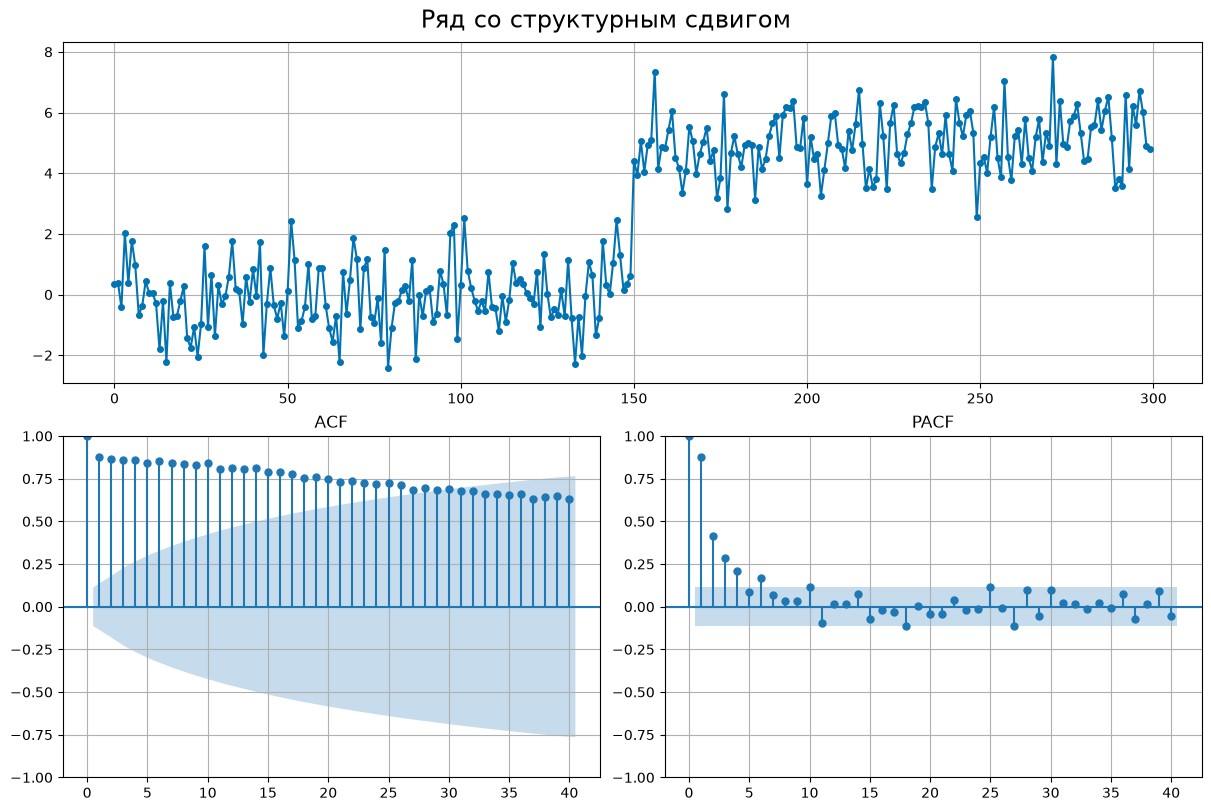

<Figure size 1300x600 with 0 Axes>

In [35]:
tsdisplay(broken, lags=40, title="Ряд со структурным сдвигом")
plt.show()

ACF затухает **медленно** — картинка неотличима от той, что мы видели у
случайного блуждания в ноутбуке `01`. И понятно почему: любые два
наблюдения по одну сторону от сдвига «согласованы» друг с другом (оба
высокие или оба низкие), что механически создаёт высокую автокорреляцию
на всех лагах.

Формальные тесты:

In [36]:
pd.DataFrame(
    [
        unit_root_report(broken, "ряд со сдвигом"),
        unit_root_report(broken.diff().dropna(), "его первая разность"),
    ]
).set_index("ряд")

,ADF p,ADF: ед. корень?,KPSS p,KPSS: стационарен?,вердикт
ряд,,,,,
ряд со сдвигом,0.7804,да,0.01,нет,нестационарен ⇒ нужна разность
его первая разность,0.0000,нет,0.10,да,стационарен


Первая строка: «нестационарен ⇒ нужна разность». Все три инструмента —
график, ACF, тесты — единодушно дают **неверный** ответ.

## 8.2. Почему разность здесь — плохое решение

Формально разность «работает»: вторая строка таблицы говорит, что
продифференцированный ряд стационарен. Но посмотрим, что мы получили.

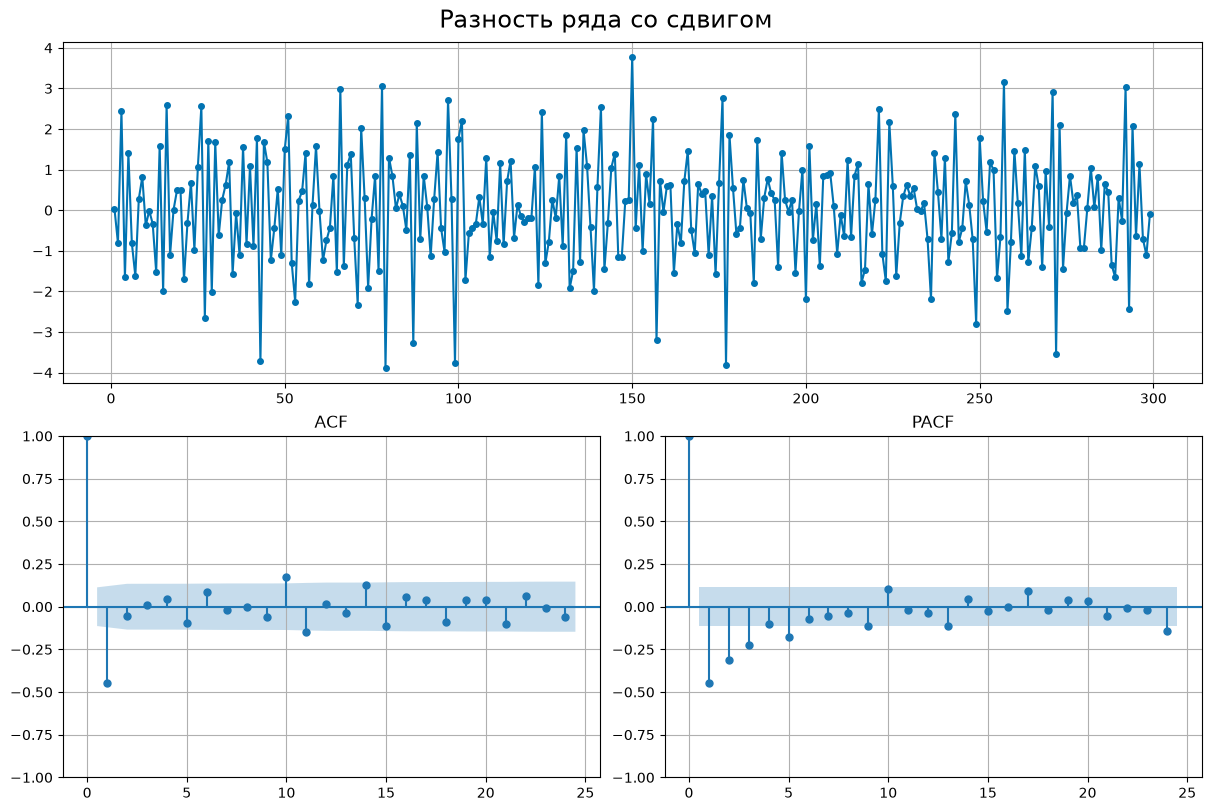

<Figure size 1300x600 with 0 Axes>

ACF(1) разности: -0.446


In [37]:
tsdisplay(broken.diff().dropna(), lags=24, title="Разность ряда со сдвигом")
plt.show()

print(f"ACF(1) разности: {acf(broken.diff().dropna(), nlags=1)[1]:.3f}")

ACF(1) ≈ $-0.44$ — знакомая подпись сверхдифференцирования из раздела 5.
До теоретических $-0.5$ немного не дотягивает ровно из-за самого сдвига:
в точке $t=150$ разность даёт одиночный выброс величиной 5, который
«разбавляет» отрицательную автокорреляцию. Но природа явления та же — мы
взяли разность у ряда, который в ней не нуждался, и получили MA(1) с
$\theta \approx -1$ плюс выброс.

Практические потери:

* дисперсия остатков выросла примерно вдвое ⇒ **интервалы прогноза шире**;
* модель на границе обратимости ⇒ проблемы с оценкой;
* и главное — **мы потеряли объяснение**. Модель говорит «ряд
  нестационарен», хотя правда состоит в том, что «первого июля поменялся
  тариф». Первая формулировка бесполезна для бизнеса, вторая — ценна.

## 8.3. Правильное решение: ступенчатая экзогенная переменная

Если мы знаем (или нашли) момент сдвига, его нужно моделировать явно —
добавить в модель бинарную переменную «после сдвига». Это превращает
ARIMA в **ARIMAX** — ARIMA с экзогенными регрессорами.

In [38]:
model_exog = ARIMA(broken, order=(1, 0, 0), exog=step, trend="c").fit()
print(model_exog.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0564      0.088     -0.641      0.521      -0.229       0.116
x1             5.0795      0.129     39.313      0.000       4.826       5.333
ar.L1          0.1012      0.059      1.705      0.088      -0.015       0.218
sigma2         0.9993      0.084     11.859      0.000       0.834       1.164


Читаем таблицу коэффициентов:

* `x1` — коэффициент при ступеньке — оценён примерно как **5.05** при
  истинном значении 5.0. Модель нашла величину сдвига.
* `ar.L1` — коэффициент AR(1) — практически ноль, и он незначим. Модель
  честно говорит: «после учёта сдвига в ряду не осталось никакой
  автокорреляционной структуры» — то есть это белый шум, чем он и является.

Сравним с моделью на разности.

/Users/a.p.chikov/PycharmProjects/time-series-cu-2026/week_4/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/a.p.chikov/PycharmProjects/time-series-cu-2026/week_4/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/a.p.chikov/PycharmProjects/time-series-cu-2026/week_4/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(da

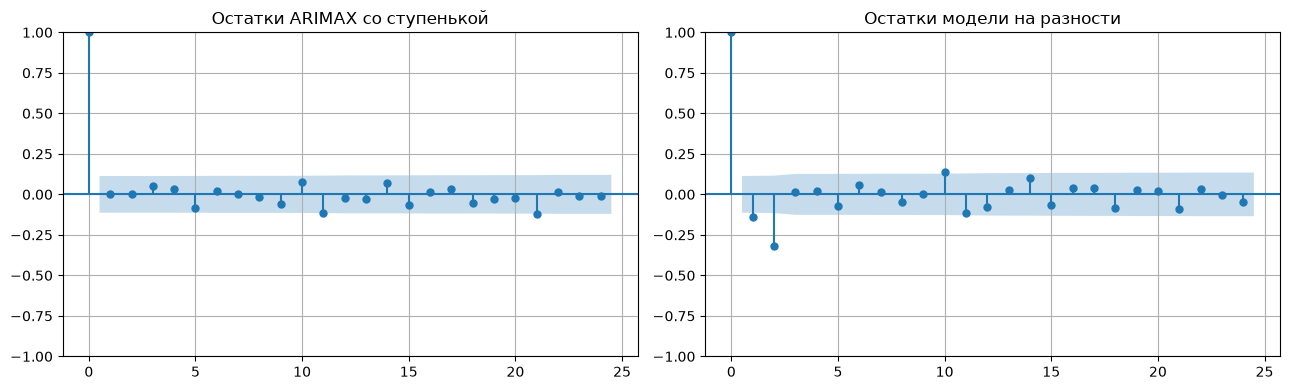

,AIC,std остатков
модель,,
"ARIMAX(1,0,0) + ступенька",859.2,1.001
"ARIMA(1,0,0) на разности",974.3,1.223


In [39]:
model_diff = ARIMA(broken.diff().dropna(), order=(1, 0, 0), trend="c").fit()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(model_exog.resid, lags=24, ax=axes[0], title="Остатки ARIMAX со ступенькой")
plot_acf(model_diff.resid, lags=24, ax=axes[1], title="Остатки модели на разности")
fig.tight_layout()
plt.show()

pd.DataFrame(
    [
        {"модель": "ARIMAX(1,0,0) + ступенька", "AIC": round(model_exog.aic, 1), "std остатков": round(model_exog.resid.std(ddof=1), 3)},
        {"модель": "ARIMA(1,0,0) на разности", "AIC": round(model_diff.aic, 1), "std остатков": round(model_diff.resid.std(ddof=1), 3)},
    ]
).set_index("модель")

У модели со ступенькой остатки чистые, а стандартное отклонение остатков
примерно в $\sqrt{2}$ раза меньше. Прямой выигрыш в ширине интервалов
прогноза.

## 8.4. А если момент сдвига неизвестен?

В примере выше мы знали, где сдвиг. В жизни его надо найти. Варианты:

1. **Спросить у бизнеса.** Самый надёжный способ. Аномалия в данных почти
   всегда соответствует известному событию.
2. **Ruptures, CUSUM, байесовские методы** обнаружения разладки — за
   рамками курса.


---
# 9. Мостик к семинару 5: сезонная разность

Всё, что было выше, касалось обычной разности. Но у сезонных рядов есть
вторая ось нестационарности — уровень может уплывать **от цикла к циклу**.
Полностью SARIMA мы разберём в семинаре 5; здесь — только измерительная
часть: как понять, нужна ли сезонная разность.

## 9.1. Что такое сезонная разность

Сезонная разность с периодом $m$ вычитает значение год назад:

$$y^{(m)}_t = y_t - y_{t-m} = (1 - L^m) y_t$$

Для месячных данных $m=12$: «сколько прибавилось по сравнению с тем же
месяцем прошлого года». В pandas это `y.diff(12)`.

⚠️ Не путайте с $d$! `y.diff()` — разность соседей, `y.diff(12)` —
сезонная разность. Они делают разные вещи и обозначаются разными буквами:
$d$ и $D$.

Посмотрим на `log(a10)`.

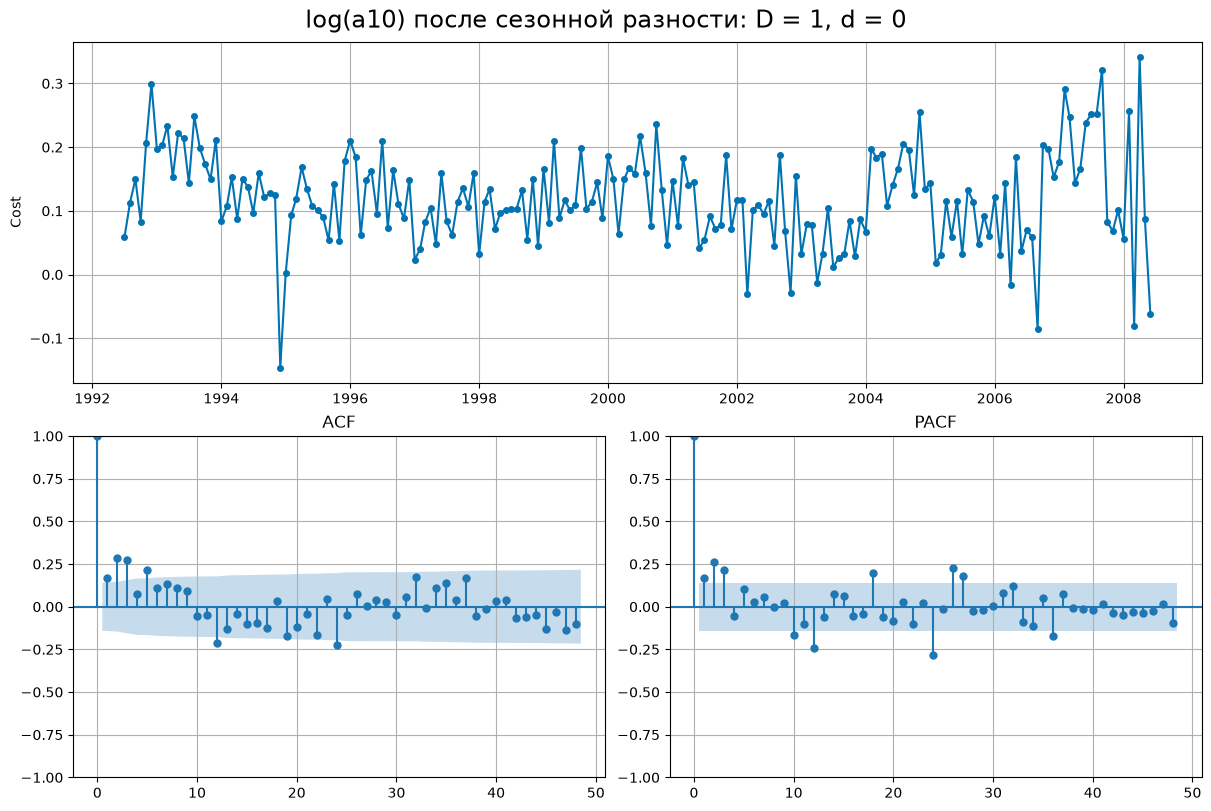

<Figure size 1300x600 with 0 Axes>

In [40]:
log_a10 = np.log(a10)

tsdisplay(log_a10.diff(12).dropna(), lags=48, title="log(a10) после сезонной разности: D = 1, d = 0")
plt.show()

Сезонные всплески на лагах 12, 24, 36 исчезли — сезонность убрана. Ряд
колеблется вокруг постоянного положительного уровня (это годовой темп
роста), ACF затухает быстро. Похоже, одной сезонной разности уже хватило.

Проверим формально — теми же инструментами, что и в разделе 3.

In [41]:
pd.DataFrame(
    [
        unit_root_report(log_a10, "log(a10)"),
        unit_root_report(log_a10.diff(12).dropna(), "log(a10), D = 1"),
    ]
).set_index("ряд")

,ADF p,ADF: ед. корень?,KPSS p,KPSS: стационарен?,вердикт
ряд,,,,,
log(a10),0.7574,да,0.01,нет,нестационарен ⇒ нужна разность
"log(a10), D = 1",0.0000,нет,0.10,да,стационарен


Подтверждается: после сезонной разности оба теста согласны, что ряд
стационарен. Обычная разность **не нужна**.

## 9.2. Порядок применения: почему сезонная разность идёт первой

> 🔑 **Если сомневаетесь, нужны ли обе разности, сезонную берите первой.**
> Причина ровно та, которую мы сейчас увидели: сезонная разность с шагом
> $m$ убирает не только сезонность, но и значительную часть тренда
> (она вычитает значение год назад — а за год ряд успел подрасти). После
> неё обычная разность часто оказывается уже лишней.

Математически операторы $(1-L)$ и $(1-L^m)$ коммутируют, так что от
порядка **вычислений** результат не зависит. Зависит **решение** — брать
ли вторую разность вообще. Посмотрим, во что обойдётся лишний шаг.

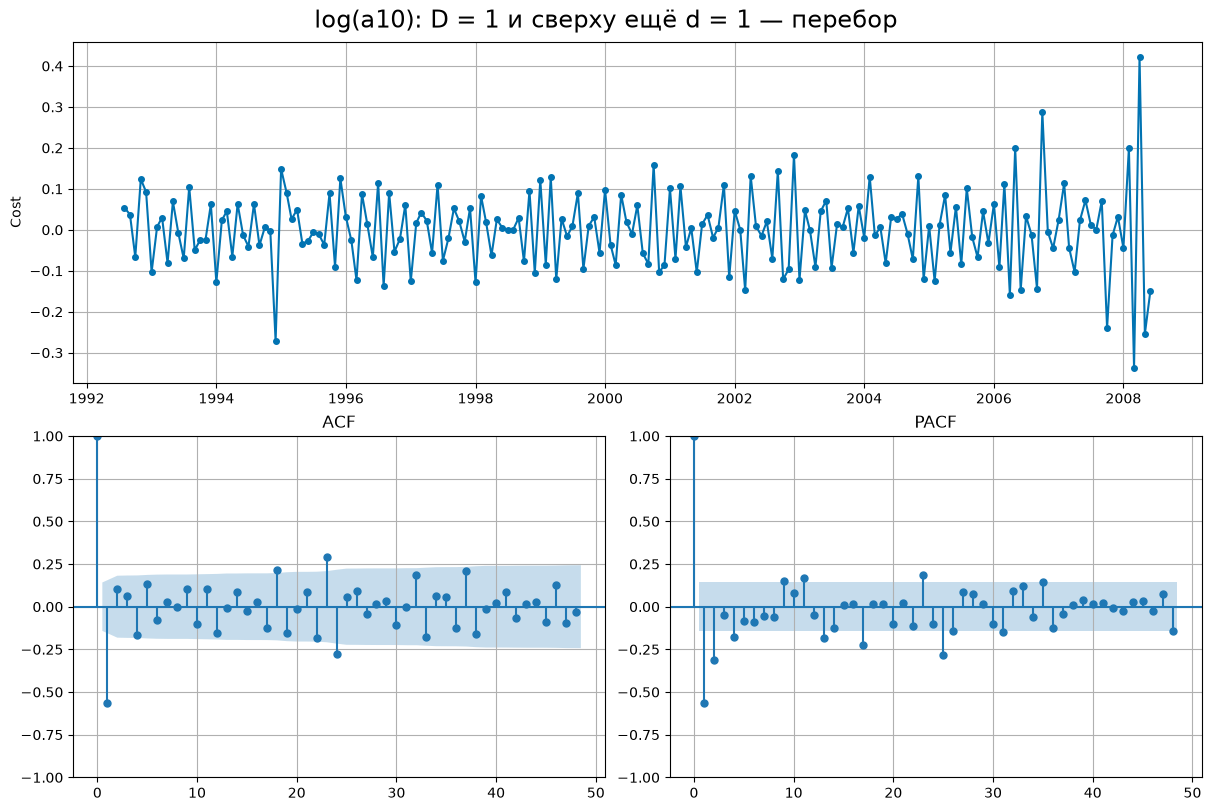

<Figure size 1300x600 with 0 Axes>

In [42]:
tsdisplay(log_a10.diff(12).diff().dropna(), lags=48, title="log(a10): D = 1 и сверху ещё d = 1 — перебор")
plt.show()

In [43]:
pd.DataFrame(
    [
        {
            "ряд": name,
            "n": len(z),
            "std": round(z.std(ddof=1), 4),
            "ACF(1)": round(acf(z, nlags=1)[1], 3),
        }
        for name, z in [
            ("log(a10), D=1, d=0", log_a10.diff(12).dropna()),
            ("log(a10), D=1, d=1", log_a10.diff(12).diff().dropna()),
        ]
    ]
).set_index("ряд")

,n,std,ACF(1)
ряд,,,
"log(a10), D=1, d=0",192,0.0737,0.169
"log(a10), D=1, d=1",191,0.0943,-0.561


Оба признака передозировки, которые мы разбирали в разделах 5 и 6,
зажигаются одновременно:

* `std` **вырос** с 0.074 до 0.094 (правило 3);
* `ACF(1)` провалилась к $-0.56$, то есть **ниже $-0.5$** (правило 2).

Итог для `a10`: $\lambda = 0$ (логарифм), $D = 1$, $d = 0$, $m = 12$.
Одной сезонной разности достаточно.

🔍 Этот пример стоит запомнить: интуиция «ряд растёт ⇒ значит нужна
обычная разность» здесь подводит. Тренд уже съеден сезонной разностью, и
добавлять $d=1$ «на всякий случай» — прямой путь к
сверхдифференцированной модели.

## 9.3. Сила сезонности и тренда

Как решить формально, нужна ли сезонная разность? Хайндман предлагает
измерить **силу сезонности** через STL-разложение
$y_t = T_t + S_t + \varepsilon_t$:

$$
F_S = \max\left(0,\ 1 - \frac{\mathrm{Var}(\varepsilon_t)}{\mathrm{Var}(S_t + \varepsilon_t)}\right),
\qquad
F_T = \max\left(0,\ 1 - \frac{\mathrm{Var}(\varepsilon_t)}{\mathrm{Var}(T_t + \varepsilon_t)}\right)
$$

Логика прозрачна: если сезонная компонента объясняет большу́ю часть
вариации «сезонность + шум», дробь мала и $F_S$ близка к 1. Если
сезонности нет, $S_t \approx 0$, дробь близка к 1 и $F_S \approx 0$.
Обе меры лежат в $[0, 1]$.

In [44]:
def stl_strength(y, period, name=""):
    """Сила сезонности и тренда по STL-разложению (Wang, Smith & Hyndman)."""
    y = pd.Series(y).dropna()
    res = STL(y, period=period, robust=True).fit()
    var_resid = res.resid.var(ddof=1)
    return {
        "ряд": name,
        "F_S (сезонность)": round(max(0.0, 1 - var_resid / (res.seasonal + res.resid).var(ddof=1)), 3),
        "F_T (тренд)": round(max(0.0, 1 - var_resid / (res.trend + res.resid).var(ddof=1)), 3),
    }


us_change = pd.read_csv("../data/us_change.csv", parse_dates=["Time"]).set_index("Time")

pd.DataFrame(
    [
        stl_strength(log_a10, 12, "log(a10), m=12"),
        stl_strength(np.log(pd.read_csv("../data/AirPassengers.csv")["#Passengers"]), 12, "log(AirPassengers), m=12"),
        stl_strength(us_change["Consumption"], 4, "US Consumption, m=4"),
        stl_strength(pd.Series(RNG.normal(0, 1, 240)), 12, "белый шум, m=12"),
    ]
).set_index("ряд")

,F_S (сезонность),F_T (тренд)
ряд,,
"log(a10), m=12",0.899,0.993
"log(AirPassengers), m=12",0.959,0.996
"US Consumption, m=4",0.008,0.404
"белый шум, m=12",0.251,0.093


* `log(a10)` — $F_S \approx 0.9$: сезонность очень сильная.
* `log(AirPassengers)` — тоже высокая.
* `US Consumption` — $F_S$ близка к нулю: сезонности практически нет
  (данные уже сезонно сглажены).
* белый шум — $F_S \approx 0$, как и ожидалось. Полезная проверка на
  вменяемость: мера не находит сезонность там, где её нет.

## 9.4. Правило и его автоматизация

> 🔑 **Правило.** Если $F_S > 0.64$, берём сезонную разность ($D=1$),
> иначе $D=0$.

Порог 0.64 — эмпирический, подобранный Хайндманом по большому набору
рядов. Именно эту процедуру реализует `nsdiffs` с `test='seas'`.

In [45]:
from statsforecast.arima import nsdiffs as sf_nsdiffs


def nsdiffs_manual(y, period, threshold=0.64, max_D=1):
    """Выбор D по силе сезонности: аналог statsforecast.arima.nsdiffs(test='seas')."""
    z = pd.Series(y).dropna()
    D = 0
    while D < max_D:
        fs = stl_strength(z, period)["F_S (сезонность)"]
        if fs <= threshold:
            break
        z = z.diff(period).dropna()
        D += 1
    return D


checks = {
    "log(a10), m=12": (log_a10, 12),
    "a10, m=12": (a10, 12),
    "log(AirPassengers), m=12": (np.log(pd.read_csv("../data/AirPassengers.csv")["#Passengers"]), 12),
    "US Consumption, m=4": (us_change["Consumption"], 4),
    "белый шум, m=12": (pd.Series(RNG.normal(0, 1, 240)), 12),
}

pd.DataFrame(
    [
        {
            "ряд": name,
            "F_S": stl_strength(s, m)["F_S (сезонность)"],
            "наш D": nsdiffs_manual(s, m),
            "statsforecast D": sf_nsdiffs(pd.Series(s).dropna().to_numpy(dtype=float), period=m),
        }
        for name, (s, m) in checks.items()
    ]
).set_index("ряд")

,F_S,наш D,statsforecast D
ряд,,,
"log(a10), m=12",0.899,1,1
"a10, m=12",0.854,1,1
"log(AirPassengers), m=12",0.959,1,1
"US Consumption, m=4",0.008,0,0
"белый шум, m=12",0.054,0,0


Ответы совпадают. Небольшие расхождения в самом $F_S$ возможны:
`statsforecast` считает разложение через MSTL со своими настройками, мы —
через `STL(robust=True)`. Но по обе стороны порога 0.64 ряды
распределились одинаково.

## 9.5. Полный рецепт для `a10`

Соберём всё, что мы сегодня разобрали, в один проход по ряду `a10`.

In [46]:
print("ШАГ 1. График → размах растёт ⇒ нужно преобразование дисперсии.")
print(f"  λ (MLE) = {boxcox_normmax(a10.to_numpy(), method='mle'):.3f}")
print("  → округляем до λ = 0, берём логарифм.\n")

w = np.log(a10)

D = nsdiffs_manual(w, 12)
print(f"ШАГ 2. Сезонная разность: F_S = {stl_strength(w, 12)['F_S (сезонность)']} > 0.64  ⇒  D = {D}")
w_seasonal = w.diff(12).dropna() if D else w

d = ndiffs_manual(w_seasonal, verbose=False)
print(f"ШАГ 3. Обычная разность после сезонной: d = {d}")
w_final = w_seasonal.diff(d).dropna() if d else w_seasonal

print(f"\nШАГ 4. Проверка на передозировку: ACF(1) = {acf(w_final, nlags=1)[1]:.3f}  (должна быть > -0.5)")
print(f"       {'✅ всё в порядке' if acf(w_final, nlags=1)[1] > -0.5 else '⚠️ подозрение на сверхдифференцирование'}")

print(f"\nИТОГ: λ = 0, d = {d}, D = {D}, m = 12")
print(f"      Модель будет иметь вид SARIMA(p, {d}, q)(P, {D}, Q)[12] на log(a10).")

ШАГ 1. График → размах растёт ⇒ нужно преобразование дисперсии.
  λ (MLE) = 0.062
  → округляем до λ = 0, берём логарифм.

ШАГ 2. Сезонная разность: F_S = 0.899 > 0.64  ⇒  D = 1
ШАГ 3. Обычная разность после сезонной: d = 0

ШАГ 4. Проверка на передозировку: ACF(1) = 0.169  (должна быть > -0.5)
       ✅ всё в порядке

ИТОГ: λ = 0, d = 0, D = 1, m = 12
      Модель будет иметь вид SARIMA(p, 0, q)(P, 1, Q)[12] на log(a10).


In [47]:
pd.DataFrame([unit_root_report(w_final, "log(a10) после D=1, d=1")]).set_index("ряд")

,ADF p,ADF: ед. корень?,KPSS p,KPSS: стационарен?,вердикт
ряд,,,,,
"log(a10) после D=1, d=1",0.0,нет,0.1,да,стационарен


Оба теста подтверждают: ряд приведён к стационарности. Осталось подобрать
$p, q, P, Q$ — но это уже семинар 2 (несезонная часть) и семинар 5
(сезонная).

---
# Итоги

* **Порядок действий важен .** Сначала стабилизируем
  дисперсию, потом уровень. На ВВП США без логарифма выбор $d$ повис на
  границе (KPSS p = 0.078) и стал зависеть от реализации теста:
  наш `ndiffs_manual` дал $d=1$, `statsforecast` — $d=2$. С логарифмом обе
  реализации уверенно дают $d=1$ (разделы 1, 3.4, 7.2).
* **Бокс-Кокс** — семейство преобразований с параметром $\lambda$;
  $\lambda=0$ даёт логарифм. Подбирается по MLE,
  округляется до «красивого» значения — минимум целевой функции пологий
  (раздел 2).
* **Вторая разность — это `y.diff().diff()`, а не `y.diff(2)`** (раздел 3.1).
* **Детерминированный тренд лечится детрендированием, стохастический —
  разностью.** Перепутать = либо внести артефакт MA(1) с $\theta=-1$,
  либо не убрать нестационарность вовсе. Отличить помогает спецификация
  `'ct'` в ADF (раздел 4).
* **Сверхдифференцирование (правило 2):** признак — `ACF(1)` $\le -0.5$ и
  «пилящая» ACF. Одну лишнюю разность MA-часть обычно компенсирует
  коэффициентом $\theta_1 \approx -1$ (на границе обратимости), две — уже
  нет: дисперсия удваивается, интервалы прогноза разъезжаются. Ни AIC, ни
  ADF/KPSS от передозировки не защищают (раздел 5).
* **Правило 3 (минимум `std`)** — быстрая эвристика, но она не отличает
  детерминированный тренд от стохастического. Всегда проверяйте ответ по
  ACF (раздел 6).
* **Автоматический выбор $d$** — цикл «KPSS → разность → KPSS». Наша
  реализация совпала с `statsforecast.ndiffs` везде, кроме пограничного
  ВВП без логарифма; и обе одинаково ошибаются на детерминированном
  тренде, потому что тест внутри вызывается со спецификацией `'c'`
  (раздел 7).
* **Структурный сдвиг (правило 18)** даёт медленно затухающую ACF и
  ложный вердикт «нужна разность». Лечится ступенчатой экзогенной
  переменной в ARIMAX, а точку сдвига можно найти тестом Зивота-Эндрюса
  (раздел 8).
* **Сезонная разность:** решение принимается по силе сезонности
  $F_S > 0.64$ из STL-разложения. Сезонную разность берут первой — она
  съедает и часть тренда, после чего обычная часто оказывается лишней.
  Для `a10` итог: $\lambda = 0$, $D = 1$, $d = 0$ (раздел 9).

## Итоговая шпаргалка по диагностике

| Что видим | Что это значит | Что делать |
|---|---|---|
| размах растёт со временем | нестабильная дисперсия | log / Бокс-Кокс |
| ACF затухает медленно и положительна | нужна разность | `.diff()` |
| ACF(1) $\le -0.5$, «пила» | передозировка | уменьшить $d$ |
| ACF затухает медленно, но на графике ступенька | структурный сдвиг | экзогенная переменная |
| всплески ACF на лагах $m, 2m, 3m$ | сезонность | `.diff(m)`, если $F_S > 0.64$ |
| ADF `'ct'` отвергает, ADF `'c'` — нет | детерминированный тренд | детрендирование |
